# **Planeación estratégica basada en analítica prescriptiva - Evidencia Final.**


In [ ]:
#pip install pmdarima

In [ ]:
#pip install numpy==1.26.4

In [3]:
import numpy
print(numpy.__version__)

2.0.2


In [ ]:
#pip install pingouin

In [ ]:
#pip install sweetviz

## Librerias

In [1]:
# Series de Tiempo
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.tsaplots import plot_predict
import pmdarima as pm
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
from warnings import simplefilter
import numpy as np
import matplotlib.ticker as ticker
from statsmodels.tsa.stattools import adfuller

In [2]:
# Pruebas de Hipótesis
from statsmodels.formula.api import ols
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.stats import shapiro
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency

In [3]:
#EDA
#import pingouin as pg
#import sweetviz as sv
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

## Pruebas de Hipótesis

#### Base de Datos

In [4]:
H_data = pd.read_excel("Encuesta_Eventos_Nuevo_Leon.xlsx", sheet_name="Encuesta_PalNorte")
H_data = H_data.drop(columns=["Name"])

In [5]:
H_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 16 columns):
 #   Column                                                                                                  Non-Null Count  Dtype 
---  ------                                                                                                  --------------  ----- 
 0   ID                                                                                                      178 non-null    int64 
 1   Start time                                                                                              178 non-null    object
 2   Completion time                                                                                         178 non-null    object
 3   Email                                                                                                   178 non-null    object
 4   ¿Cómo compró sus boletos para el festival?                                                        

In [6]:
new_columns = [
    "ID",
    "Inicio",
    "Finalizacion",
    "Email",
    "Compra_Boletos",
    "Dias_Asistencia",
    "Presupuesto_Boletos",
    "Categoria_Boleto",
    "Ciudad_Origen",
    "Presupuesto_Alojamiento",
    "Gasto_Alimentos",
    "Gasto_Transporte",
    "Otros_Gastos",
    "Primera_Vez",
    "Rango_Edad",
    "Ocupacion"
]

H_data.columns = new_columns

In [7]:
conversion_alimentos = {
    'Menos de $500 MXN (pesos)': 250,
    'Entre $500 y $1,000 MXN (pesos)': 750,
    'Más de $1,000 MXN (pesos)': 1250
}

conversion_gasto = {
    'Menos de $300 MXN (pesos) por día': 150,
    'Entre $300 y $700 MXN (pesos) por día': 550,
    'Más de $700 MXN (pesos) por día': 950
}
conversion_boletos = {
    'Menos de $2,000 MXN (pesos)': 1500,
    'Entre $2,000 y $4,000 MXN (pesos)': 3000,
    'Más de $4,000 MXN (pesos)': 4500
}
conversion_alojamiento = {
    'No aplica (me hospedo con familiares/amigos)': 0,
    'Menos de $1,000 MXN (pesos) por noche': 500,
    'Entre $1,000 y $3,000 MXN (pesos) por noche': 2000,
    'Más de $3,000 MXN (pesos) por noche':4000
}


H_data['Gasto_Alimentos_Num'] = H_data['Gasto_Alimentos'].map(conversion_alimentos)
H_data['Gasto_Transporte_Num'] = H_data['Gasto_Transporte'].map(conversion_gasto)
H_data['Presupuesto_Alojamiento_Num'] = H_data['Presupuesto_Alojamiento'].map(conversion_alojamiento)
H_data['Presupuesto_Boletos_Num'] = H_data['Presupuesto_Boletos'].map(conversion_boletos)
H_data['Gasto_Total'] = H_data['Gasto_Alimentos_Num'] + H_data['Gasto_Transporte_Num'] + H_data['Presupuesto_Alojamiento_Num'] + H_data['Presupuesto_Boletos_Num']

### 1.-ANOVA Ciudad_Origen vs Gasto Total (Alimentos + Boletos + Alojamiento + Transporte)

¿Existe una diferencia estadísticamente significativa en el gasto total promedio durante el festival entre los asistentes que residen en Monterrey, aquellos que residen en otras partes de Nuevo León (fuera de Monterrey), y aquellos que provienen de fuera del estado de Nuevo León?

In [9]:
modelo = ols('Gasto_Total ~ C(Ciudad_Origen)', data=H_data).fit()
anova_table = sm.stats.anova_lm(modelo, typ=2)
print(anova_table)


                        sum_sq     df          F        PR(>F)
C(Ciudad_Origen)  3.233487e+08    3.0  28.022503  7.807873e-15
Residual          6.692559e+08  174.0        NaN           NaN


#### Conclusión

- F = 28.022503 → Hay diferencias importantes entre grupos.
- p-valor = 7.807873e-15 → Es menor a 0.05, por lo tanto, Se Rechaza H₀:
- El lugar de origen sí influye en el gasto total durante el festival.

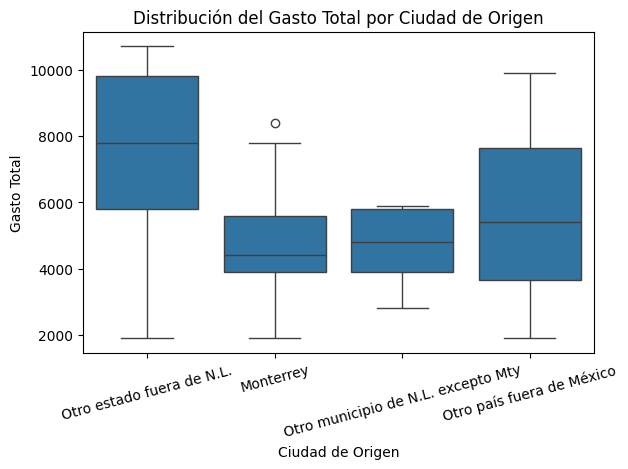

In [10]:
H_data.groupby('Ciudad_Origen')['Gasto_Total'].mean()
sns.boxplot(x='Ciudad_Origen', y='Gasto_Total', data=H_data)
plt.xticks(rotation=15)
plt.title('Distribución del Gasto Total por Ciudad de Origen')
plt.xlabel('Ciudad de Origen')
plt.ylabel('Gasto Total')
plt.tight_layout()
plt.show()

### 2-ANOVA Rango_Edad vs Presupuesto_Boletos

¿El rango de edad de los asistentes al festival se relaciona significativamente con el monto promedio gastado en boletos para el evento?

In [11]:
modelo = ols('Presupuesto_Boletos_Num ~ C(Rango_Edad)', data=H_data).fit()
anova_table = sm.stats.anova_lm(modelo, typ=2)
print(anova_table)

                     sum_sq     df         F    PR(>F)
C(Rango_Edad)  3.642748e+06    4.0  0.871062  0.482535
Residual       1.808699e+08  173.0       NaN       NaN


#### Conclusión

- F = 0.871062
- p-valor = 0.482535 → Es mayor a 0.05, por lo tanto, No se Rechaza H₀:
- El rango de edad no influye en el monto promedio gastado en boletos.

### 3.-ANOVA Ocupacion vs Gasto_Alimentos

¿La situación de empleo (ej. estudiante, empleado tiempo completo, empleado medio tiempo, desempleado) de los asistentes influye de manera significativa en su gasto promedio en alimentos y bebidas dentro del festival?

In [14]:
modelo = ols('Gasto_Alimentos_Num ~ C(Ocupacion)', data=H_data).fit()
anova_table = sm.stats.anova_lm(modelo, typ=2)
print(anova_table)

                    sum_sq     df         F    PR(>F)
C(Ocupacion)  1.496934e+06    6.0  2.056422  0.060825
Residual      2.074604e+07  171.0       NaN       NaN


#### Conclusión

- F = 2.056422
- p-valor = 0.060825 → Es mayor a 0.05, por lo tanto, No se Rechaza H₀:
- La ocupación no influye en el gasto promedio en alimentos dentro del festival.
- Al 90% de confianza sí hay una relación.

### 4.-ANOVA Rango_Edad vs Gasto Alimentos y Bebidas

In [16]:
H_data['P_Gasto_Alimentos'] = H_data['Gasto_Alimentos_Num'] / H_data['Gasto_Total']

¿La proporción del gasto total que los asistentes destinan a "alimentos y bebidas" difiere significativamente entre los distintos rangos de edad identificados?

In [17]:
modelo = ols('P_Gasto_Alimentos ~ C(Rango_Edad)', data=H_data).fit()
anova_table = sm.stats.anova_lm(modelo, typ=2)
print(anova_table)

                 sum_sq     df         F    PR(>F)
C(Rango_Edad)  0.015067    4.0  0.704958  0.589557
Residual       0.924364  173.0       NaN       NaN


#### Conclusión

- F = 0.704958
- p-valor = 0.589557 → Es mayor a 0.05, por lo tanto, No se Rechaza H₀:
- La proporción del gasto total que los asistentes destinan en alimentos y bebidas no difieren significativamente entre los rangos de edad.

### 5.-Prueba t Ciudad_Origen vs Presupuesto_Alojamiento

In [18]:
foraneos = H_data[(H_data['Ciudad_Origen'].isin(['Otro estado fuera de N.L.', 'Otro país fuera de México'])) &
                  (H_data['Presupuesto_Alojamiento'].notna())]

Entre los asistentes que no residen en el área metropolitana de Monterrey, ¿existe una diferencia significativa en el gasto promedio en hospedaje entre aquellos que provienen de otros estados de México en comparación con aquellos que provienen del extranjero?

In [19]:
grupo_mexico = foraneos.loc[foraneos['Ciudad_Origen'] == 'Otro estado fuera de N.L.']['Presupuesto_Alojamiento_Num']
grupo_extranjero = foraneos.loc[foraneos['Ciudad_Origen'] == 'Otro país fuera de México']['Presupuesto_Alojamiento_Num']

t_stat, p_value = ttest_ind(grupo_mexico, grupo_extranjero, equal_var=False)  # Welch's T-test (más robusta)
print(f'Estadístico t: {t_stat}, p-valor: {p_value}')

Estadístico t: 0.8411553442544198, p-valor: 0.48589337164462904


#### Conclusión

- t = 0.8411553442544198
- p-valor = 0.48589 → Es mayor a 0.05, por lo tanto, No se Rechaza H₀:
- No hay un diferencia significativa entre el gasto promedio en alojamiento entre los foráneos de México y foráneos extranjeros.

### 6.-Spearman R Gasto_Transporte  vs Gasto_Total

¿Existe una correlación estadísticamente significativa entre el monto que los asistentes gastan en transportación para llegar al festival y el monto total que gastan durante todo el evento?

In [20]:
_, p_transporte = shapiro(H_data['Gasto_Transporte_Num'].dropna())
_, p_total = shapiro(H_data['Gasto_Total'].dropna())

print(f'p-valor normalidad Gasto Transporte: {p_transporte}')
print(f'p-valor normalidad Gasto Total: {p_total}')

p-valor normalidad Gasto Transporte: 1.5969705342708997e-15
p-valor normalidad Gasto Total: 4.4561171279084236e-07


In [21]:
corr, p_val = spearmanr(H_data['Gasto_Transporte_Num'].dropna(), H_data['Gasto_Total'].dropna())
print(f'Coeficiente de Spearman: {corr}, p-valor: {p_val}')

Coeficiente de Spearman: 0.4065231746073146, p-valor: 1.7963003677395066e-08


#### Conclusión

- Rs: 0.4065231746073146
- p-value: 1.7963003677395066e-08 -> Es menor a 0.05,por lo tanto, Se rechaza H₀:
- Relación estadisticamente significativa moderada y positiva entre el gasto monto de gasto en transporte y el gasto total.

### 7.-Chi^2 Ciudad_Origen vs Presupuesto_Alojamiento

¿Existe una asociación estadísticamente significativa entre el lugar de residencia de los asistentes (considerando locales vs. foráneos en general) y si incurren o no en gastos de hospedaje?

In [22]:
def clasificar_residencia(ciudad):
    if ciudad in ['Monterrey', 'Otro municipio de N.L. excepto Mty']:
        return 'Local de N.L.'
    else:
        return 'Foráneo'

H_data['Residencia'] = H_data['Ciudad_Origen'].apply(clasificar_residencia)

H_data['Alojamiento_SiNo'] = H_data['Presupuesto_Alojamiento'].apply(
    lambda x: 'No' if 'No aplica' in x else 'Sí'
)

In [23]:
contingencia = pd.crosstab(H_data['Residencia'], H_data['Alojamiento_SiNo'])
chi2, p, dof, expected = chi2_contingency(contingencia)
print(f'Estadístico Chi-cuadrado: {chi2}')
print(f'p-valor: {p}')

Estadístico Chi-cuadrado: 79.50914242147601
p-valor: 4.799990480736076e-19


#### Conclusión

- Chi:  79.50914242147601
- p-value:4.799990480736076e-19 -> Es menor a 0.05, por lo tanto,Se Rechaza H₀:
- Hay una asociación significativa entre lugar de residencia y gasto en hospedaje.

## Pronósticos Series de Tiempo

### Base de Datos

In [39]:
pd.set_option('display.float_format', '{:,.2f}'.format)

In [24]:
df = pd.read_excel("Encuesta_Eventos_Nuevo_Leon.xlsx", sheet_name="Turismo_N.L")

In [25]:
df_copy = df.copy()
df_copy = df_copy.drop(columns=["Mes", "Año"])
df_copy.set_index('Fecha', inplace=True)

### EDA

In [26]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 252 entries, 2004-01-01 to 2024-12-01
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CDT             252 non-null    int64  
 1   CDP             252 non-null    float64
 2   COT             252 non-null    int64  
 3   POT             252 non-null    float64
 4   LLT_nat         252 non-null    int64  
 5   LLT_ext         252 non-null    int64  
 6   LLT_Total       252 non-null    int64  
 7   TNT_nat         252 non-null    int64  
 8   TNT_ext         252 non-null    int64  
 9   TNT_Total       252 non-null    int64  
 10  DOT             252 non-null    float64
 11  EPT             252 non-null    float64
 12  gasto_promedio  252 non-null    float64
 13  DET             252 non-null    float64
 14  INPC            252 non-null    float64
 15  LVA_nat         252 non-null    int64  
 16  LVA_ext         252 non-null    int64  
 17  LVA_Total       

In [ ]:
#df_copy[['CDP','COT','DET','gasto_promedio','INPC','LLT_nat','LLT_ext','EPT']].describe()

#### Normalidad

In [ ]:
normality_results = {}
for col in ['CDP', 'COT', 'DOT','DET', 'gasto_promedio', 'INPC', 'LLT_nat', 'LLT_ext', 'EPT','TPA']:
    stat, p_value = shapiro(df_copy[col])
    normality_results[col] = {'Estadístico W': stat, 'p-valor': p_value}
normality_df = pd.DataFrame(normality_results).T
normality_df['p-valor'] = normality_df['p-valor'].apply(lambda x: f"{x:.4f}")
normality_df

,Estadístico W,p-valor
CDP,0.947287,0.0000
COT,0.973723,0.0001
DOT,0.883298,0.0000
DET,0.881859,0.0000
gasto_promedio,0.955790,0.0000
INPC,0.928623,0.0000
LLT_nat,0.951069,0.0000
LLT_ext,0.982009,0.0028
EPT,0.949164,0.0000
TPA,0.945694,0.0000


#### Normalidad con Logaritmo

In [ ]:
normality_results_log = {}
for col in ['CDP', 'COT', 'DOT','DET', 'gasto_promedio', 'INPC', 'LLT_nat', 'LLT_ext', 'EPT','TPA']:
    transformed_data = np.log(df_copy[col][df_copy[col] > 0])
    stat, p_value = shapiro(transformed_data)
    normality_results_log[col] = {'Estadístico W': stat, 'p-valor': round(p_value, 4)}  # Redondeo directo
pd.DataFrame(normality_results_log).T

,Estadístico W,p-valor
CDP,0.963594,0.0000
COT,0.888507,0.0000
DOT,0.916285,0.0000
DET,0.970138,0.0000
gasto_promedio,0.951165,0.0000
INPC,0.947118,0.0000
LLT_nat,0.881376,0.0000
LLT_ext,0.908947,0.0000
EPT,0.976753,0.0004
TPA,0.917219,0.0000


### Derrama Económica Estimada

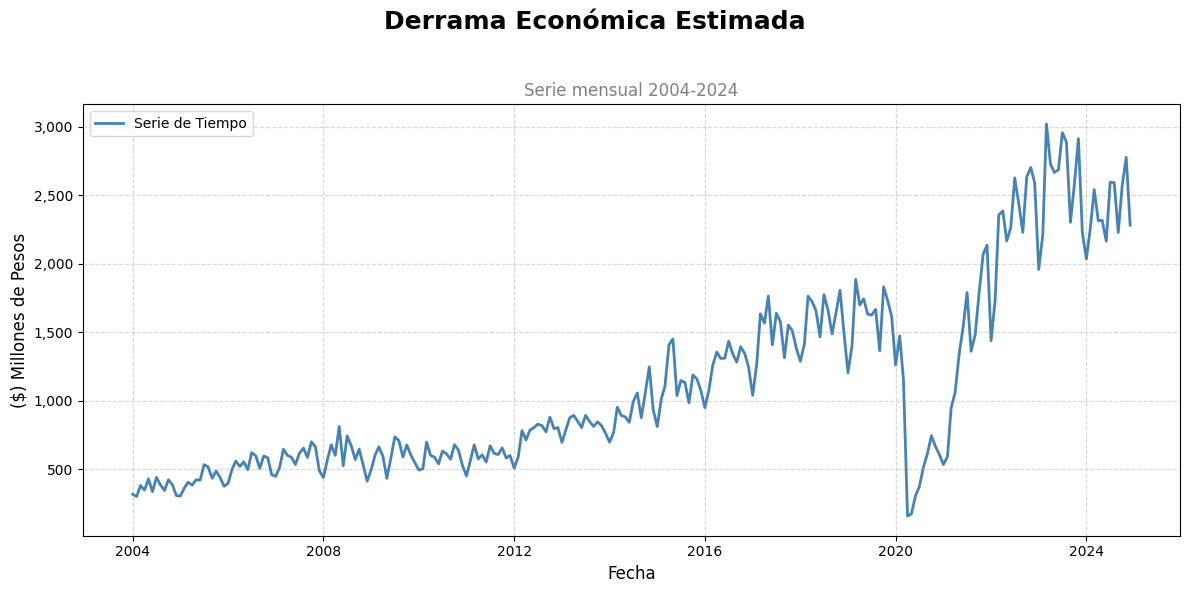

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_copy.index, df_copy['DET'], label="Serie de Tiempo", color="steelblue", linewidth=2)
plt.suptitle("Derrama Económica Estimada", fontsize=18, fontweight='bold')
plt.title("Serie mensual 2004-2024", fontsize=12, color='gray')
ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("($) Millones de Pesos", fontsize=12)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend(loc='upper left')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


#### ACF Y PACF

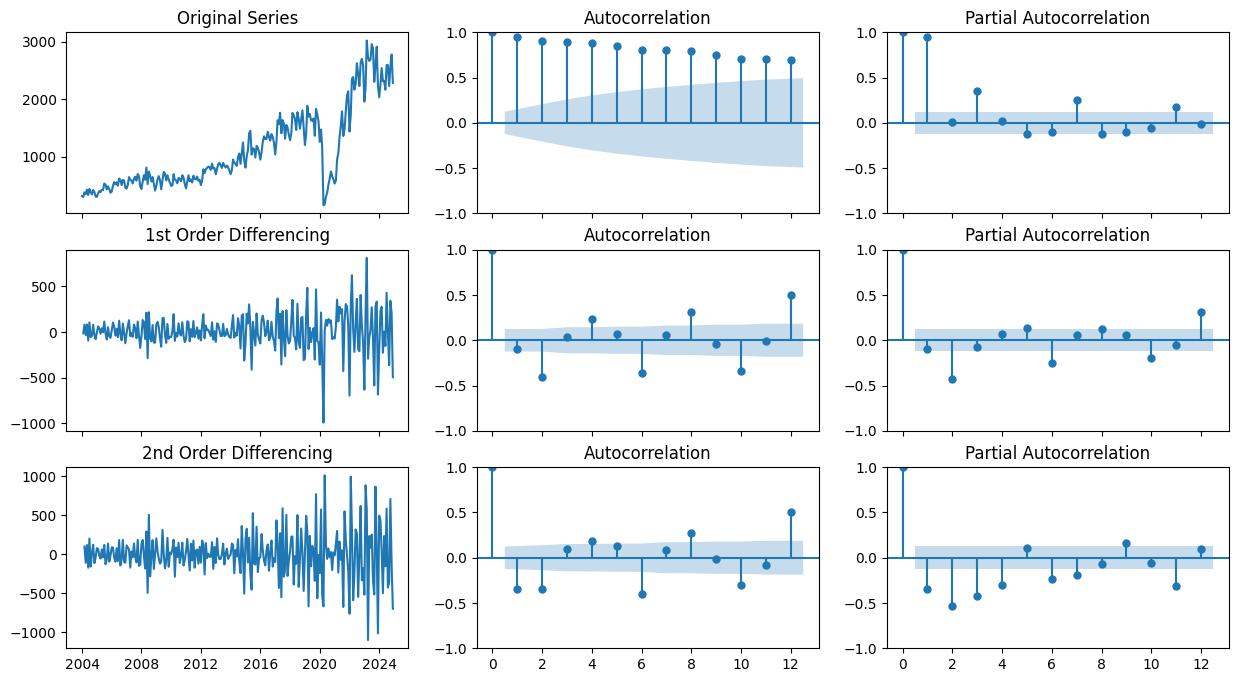

In [27]:
# Original Series
orig_data_value = df_copy['DET']
fig, axes = plt.subplots(3, 3, figsize=(15, 8),sharex='col')
axes[0, 0].plot(orig_data_value); axes[0, 0].set_title('Original Series')
plot_acf(orig_data_value, lags=12, ax=axes[0, 1])
plot_pacf(orig_data_value, lags=12, ax=axes[0, 2])

# 1st Differencing
first_diff_value = orig_data_value.diff()
axes[1, 0].plot(first_diff_value); axes[1, 0].set_title('1st Order Differencing')
plot_acf(first_diff_value.dropna(), lags=12, ax=axes[1, 1])
plot_pacf(first_diff_value.dropna(), lags=12, ax=axes[1, 2])

# 2nd Differencing
second_diff_value = orig_data_value.diff().diff()
axes[2, 0].plot(second_diff_value); axes[2, 0].set_title('2nd Order Differencing')
plot_acf(second_diff_value.dropna(), lags=12, ax=axes[2, 1])
plot_pacf(second_diff_value.dropna(), lags=12, ax=axes[2, 2])

plt.show()

In [ ]:
print("Original Series")
result = adfuller(orig_data_value, autolag='AIC')
labels = ['ADF Test Statistic', 'p-value', '# Lags Used', 'Number of Observations Used']
for value, label in zip(result[:4], labels):
    print(f"{label} : {value}")

# Evaluación del p-valor

if result[1] <= 0.05:
    print("Se rechaza la hipótesis nula. La serie ES estacionaria.")
else:
    print("No se rechaza la hipótesis nula. La serie NO ES estacionaria.")

print("--------------------------")
print("1ra Diff")
result = adfuller(first_diff_value.dropna(), autolag='AIC')
labels = ['ADF Test Statistic', 'p-value', '# Lags Used', 'Number of Observations Used']
for value, label in zip(result[:4], labels):
    print(f"{label} : {value}")

# Evaluación del p-valor

if result[1] <= 0.05:
    print("Se rechaza la hipótesis nula. La serie ES estacionaria.")
else:
    print("No se rechaza la hipótesis nula. La serie NO ES estacionaria.")

print("--------------------------")
print("2da Diff")
result = adfuller(second_diff_value.dropna(), autolag='AIC')
labels = ['ADF Test Statistic', 'p-value', '# Lags Used', 'Number of Observations Used']
for value, label in zip(result[:4], labels):
    print(f"{label} : {value}")

# Evaluación del p-valor

if result[1] <= 0.05:
    print("Se rechaza la hipótesis nula. La serie ES estacionaria.")
else:
    print("No se rechaza la hipótesis nula. La serie NO ES estacionaria.")

Original Series
ADF Test Statistic : -1.0230307233381173
p-value : 0.7447719754516042
# Lags Used : 14
Number of Observations Used : 237
No se rechaza la hipótesis nula. La serie NO ES estacionaria.
--------------------------
1ra Diff
ADF Test Statistic : -4.171744607944229
p-value : 0.0007353452779651062
# Lags Used : 13
Number of Observations Used : 237
Se rechaza la hipótesis nula. La serie ES estacionaria.
--------------------------
2da Diff
ADF Test Statistic : -10.631059177559965
p-value : 5.213128634684802e-19
# Lags Used : 10
Number of Observations Used : 239
Se rechaza la hipótesis nula. La serie ES estacionaria.


In [28]:
pct_train = 0.955
train_set, test_set= np.split(orig_data_value, [int(pct_train *len(orig_data_value))])

/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


#### Modelos

In [29]:
exog_data_value= df_copy[['CDP', 'COT', 'INPC', 'gasto_promedio', 'EPT','TPA']]

split_index = int(pct_train * len(orig_data_value))
split_index_exog = int(pct_train * len(exog_data_value))

train_set, test_set = np.split(orig_data_value, [split_index])
exog_train, exog_test = np.split(exog_data_value, [split_index_exog])

/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


#### SARIMAX con AUTO_ARIMA

In [30]:
simplefilter(action='ignore', category=FutureWarning)
smodel = pm.auto_arima((train_set),
					     start_p=1, start_q=1, exog=exog_train,
                         test='adf',
                         max_p=3, max_q=3, m=12,
                         start_P=0, seasonal=True,
                         d=1, D=1, trace=True,
                         error_action='ignore',
                         suppress_warnings=True,
                         stepwise=True)

smodel.summary()

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=inf, Time=2.12 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=3038.276, Time=0.06 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=3000.866, Time=0.32 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=2965.147, Time=0.65 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=3040.132, Time=0.16 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=2966.908, Time=1.03 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=2966.836, Time=1.68 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=3000.774, Time=0.28 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=inf, Time=2.80 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=2963.879, Time=0.39 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=2965.641, Time=2.04 sec
 ARIMA(0,1,0)(0,1,2)[12]             : AIC=2965.565, Time=1.78 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=2999.110, Time=0.21 sec
 ARIMA(0,1,0)(1,1,2)[12]             : AIC=inf, Time=2.83 sec
 ARIMA(1,1,0)(0,1,1)[12]          

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  240
Model:             SARIMAX(0, 1, 0)x(0, 1, [1], 12)   Log Likelihood               -1479.940
Date:                              Sat, 31 May 2025   AIC                           2963.879
Time:                                      21:29:32   BIC                           2970.729
Sample:                                  01-01-2004   HQIC                          2966.643
                                       - 12-01-2023                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.S.L12      -0.7328      0.036    -20.343      0.000      -0.803      -0.662
sigma2       2.59e+04   1131.256     22.894      0.000    2.37e+04    2.81e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.41   Jarque-Bera (JB):               576.09
Prob(Q):                              0.52   Prob(JB):                         0.00
Heteroskedasticity (H):              13.20   Skew:                            -1.36
Prob(H) (two-sided):                  0.00   Kurtosis:                        10.32
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

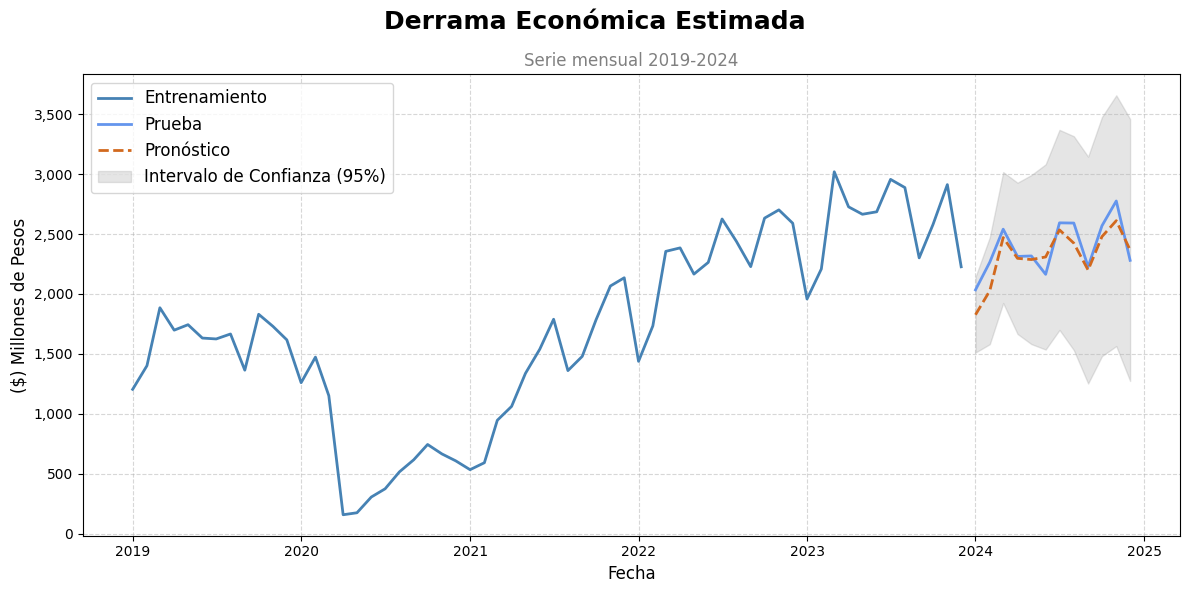

In [31]:
n_periods = 12
fitted, confint = smodel.predict(n_periods=n_periods, return_conf_int=True)
index_of_fc = pd.date_range(train_set.index[-1] + pd.DateOffset(months=1), periods = n_periods, freq='MS')

fitted_series = pd.Series(fitted, index=index_of_fc)
lower_series = pd.Series(confint[:, 0], index=index_of_fc)
upper_series = pd.Series(confint[:, 1], index=index_of_fc)

start_date = '2019-01-01'
train_filtered = train_set[train_set.index >= start_date]
test_filtered = test_set[test_set.index >= start_date]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(train_filtered, color='steelblue', linewidth=2, label='Entrenamiento')
ax.plot(test_filtered, color='cornflowerblue', linewidth=2, label='Prueba')
ax.plot(fitted_series[fitted_series.index >= start_date], color='chocolate', linestyle='--', linewidth=2, label='Pronóstico')

ax.fill_between(
    lower_series[lower_series.index >= start_date].index,
    lower_series[lower_series.index >= start_date],
    upper_series[upper_series.index >= start_date],
    color='gray', alpha=0.2, label='Intervalo de Confianza (95%)'
)

plt.suptitle("Derrama Económica Estimada", fontsize=18, fontweight='bold')
plt.title("Serie mensual 2019-2024", fontsize=12, color='gray')
ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("($) Millones de Pesos", fontsize=12)
ax.legend(loc='upper left', fontsize=12)
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
#plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### SARIMAX con StatsModels

In [32]:
sarimax_model = sm.tsa.SARIMAX(train_set,
                               exog=exog_train,  # Variables exógenas
                               order=(0, 1, 0),  # ARIMA(p,d,q)
                               seasonal_order=(0, 1, 1, 12),  # Estacionalidad (P,D,Q,m)
                               enforce_stationarity=False,
                               enforce_invertibility=False)

# Ajustar el modelo
sarimax_result = sarimax_model.fit()

# Mostrar el resumen
print(sarimax_result.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                       
Dep. Variable:                                  DET   No. Observations:                  240
Model:             SARIMAX(0, 1, 0)x(0, 1, [1], 12)   Log Likelihood               -1242.336
Date:                              Sat, 31 May 2025   AIC                           2500.672
Time:                                      21:29:45   BIC                           2527.599
Sample:                                  01-01-2004   HQIC                          2511.553
                                       - 12-01-2023                                         
Covariance Type:                                opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
CDP               -0.0068      0.029     -0.238      0.812      -0.063       0.050
COT    

#### Gráfica Forecast 24 meses

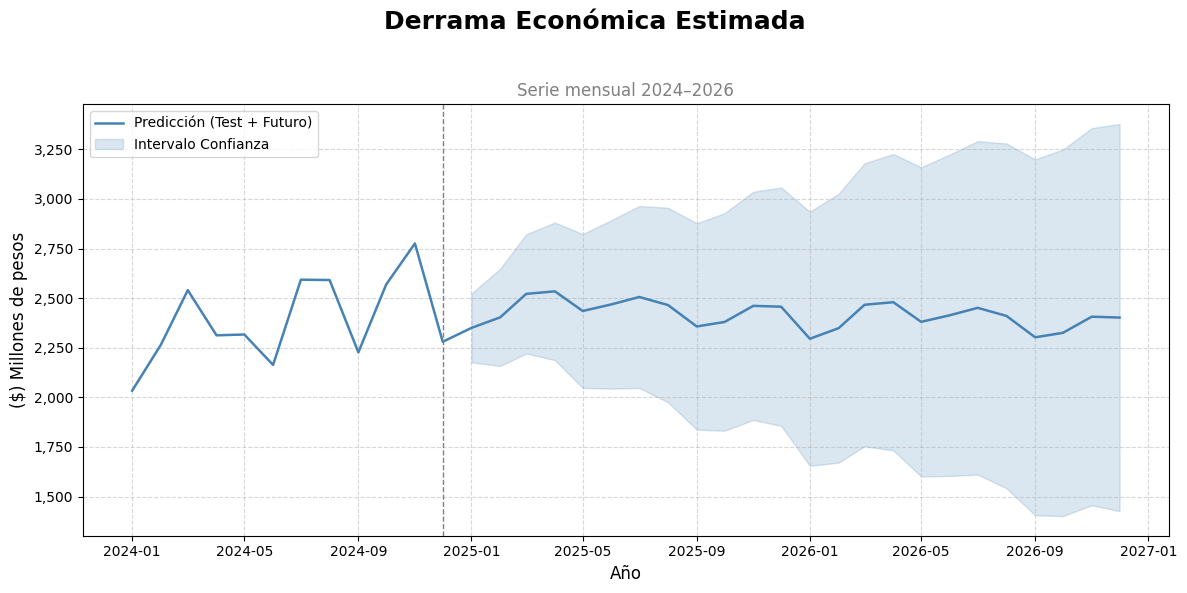

In [33]:
# Número de períodos a predecir: 24 meses
n_future_periods = 24

# ======== (1) Crear exog_future para 24 meses ========
# Usamos el promedio de las exógenas como ejemplo
exog_future = pd.DataFrame(
    np.tile(exog_test.mean().values, (n_future_periods, 1)),
    columns=exog_test.columns
)

# ======== (2) Crear índice mensual futuro ========
last_date = test_set.index[-1]
future_index = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=n_future_periods, freq='MS')

# ======== (3) Predicción del modelo SARIMAX ========
forecast = sarimax_result.get_forecast(steps=n_future_periods, exog=exog_future)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Crear series
forecast_series = pd.Series(forecast_mean.values, index=future_index)
lower_series = pd.Series(conf_int.iloc[:, 0].values, index=future_index)
upper_series = pd.Series(conf_int.iloc[:, 1].values, index=future_index)

# ======== (4) Combinar test + forecast para graficar últimos 36 meses ========
combined_series = pd.concat([test_set, forecast_series])
combined_lower = pd.concat([pd.Series([np.nan]*len(test_set), index=test_set.index), lower_series])
combined_upper = pd.concat([pd.Series([np.nan]*len(test_set), index=test_set.index), upper_series])

# ======== (5) Gráfico ========
# === (Gráfico) ===
fig, ax = plt.subplots(figsize=(12, 6))

# Línea de la serie
ax.plot(combined_series, color='steelblue', label='Predicción (Test + Futuro)', linewidth=1.8)

# Banda de intervalo de confianza
ax.fill_between(combined_series.index, combined_lower, combined_upper,
                color='steelblue', alpha=0.2, label='Intervalo Confianza')

# Línea vertical que indica el inicio de la predicción
ax.axvline(x=test_set.index[-1], color='gray', linestyle='--', linewidth=1)

# Títulos (al estilo de la imagen)
plt.suptitle("Derrama Económica Estimada", fontsize=18, fontweight='bold')
plt.title("Serie mensual 2024–2026", fontsize=12, color='gray')

# Etiquetas de los ejes
ax.set_xlabel("Año", fontsize=12)
ax.set_ylabel("($) Millones de pesos", fontsize=12)

# Formato de los números con coma (eje Y)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Rejilla
ax.grid(True, which='both', linestyle='--', alpha=0.5)

# Leyenda
ax.legend(loc='upper left')

# Ajustes finales
plt.tight_layout(rect=[0, 0, 1, 0.95])  # deja espacio para el título grande
plt.show()

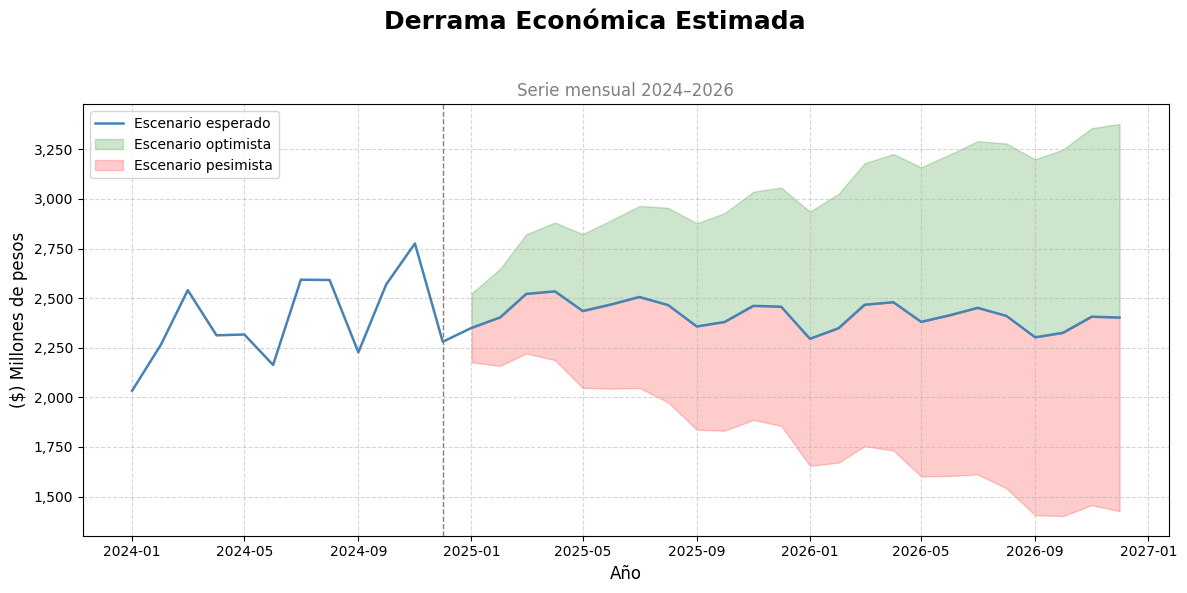

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# === Gráfico ===
fig, ax = plt.subplots(figsize=(12, 6))

# Línea central (predicción esperada)
ax.plot(combined_series, color='steelblue', label='Escenario esperado', linewidth=1.8)

# Banda superior: intervalo superior (optimista)
ax.fill_between(combined_series.index[12:], forecast_series, combined_upper[12:],
                color='green', alpha=0.2, label='Escenario optimista')

# Banda inferior: intervalo inferior (pesimista)
ax.fill_between(combined_series.index[12:], combined_lower[12:], forecast_series,
                color='red', alpha=0.2, label='Escenario pesimista')

# Línea vertical que indica el inicio de la predicción
ax.axvline(x=test_set.index[-1], color='gray', linestyle='--', linewidth=1)

# Títulos
plt.suptitle("Derrama Económica Estimada", fontsize=18, fontweight='bold')
plt.title("Serie mensual 2024–2026", fontsize=12, color='gray')

# Ejes
ax.set_xlabel("Año", fontsize=12)
ax.set_ylabel("($) Millones de pesos", fontsize=12)

# Formato del eje Y
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Rejilla
ax.grid(True, which='both', linestyle='--', alpha=0.5)

# Leyenda
ax.legend(loc='upper left')

# Ajuste de diseño
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


#### Métricas

In [35]:
Comparación = pd.DataFrame({
    "DET real": test_set,
    "Predicciones": fitted,
    "Diferencia": fitted - test_set}
)
# Filtrar las filas donde el índice corresponda a 2024
Comparación = Comparación[Comparación.index.year == 2024]

In [36]:
# RMSE
rmse = np.sqrt((Comparación['Diferencia'] ** 2).mean())

# Porcentaje de error promedio
mean_actual = Comparación['DET real'].mean()  # Asumiendo que 'Valor Real' es la columna con los valores reales
percentage_error = (rmse / mean_actual) * 100

# Imprimir los resultados
print(f"El modelo se equivoca en: {rmse:.2f} unidades respecto a los valores reales")
print(f"El porcentaje de error promedio es: {percentage_error:.2f}%")

El modelo se equivoca en: 129.75 unidades respecto a los valores reales
El porcentaje de error promedio es: 5.43%


#### Escenarios OP, ES, PO

            Escenario A (Esperado)  Escenario B (Optimista)  \
2025-01-31             2026.805490              2472.877139   
2025-02-28             2470.267899              3016.591793   
2025-03-31             2297.059024              2927.899479   
2025-04-30             2286.703847              2992.004890   
2025-05-31             2308.598961              3081.217523   
2025-06-30             2534.196119              3368.719531   
2025-07-31             2423.633115              3315.776156   
2025-08-31             2198.909368              3145.169949   
2025-09-30             2478.465090              3475.911314   
2025-10-31             2611.073756              3657.204174   
2025-11-30             2366.280285              3458.927864   
2025-12-31             1965.991441              3129.447699   
2026-01-31             2166.572265              3396.768078   
2026-02-28             2610.034674              3903.531103   
2026-03-31             2436.825800              3790.66

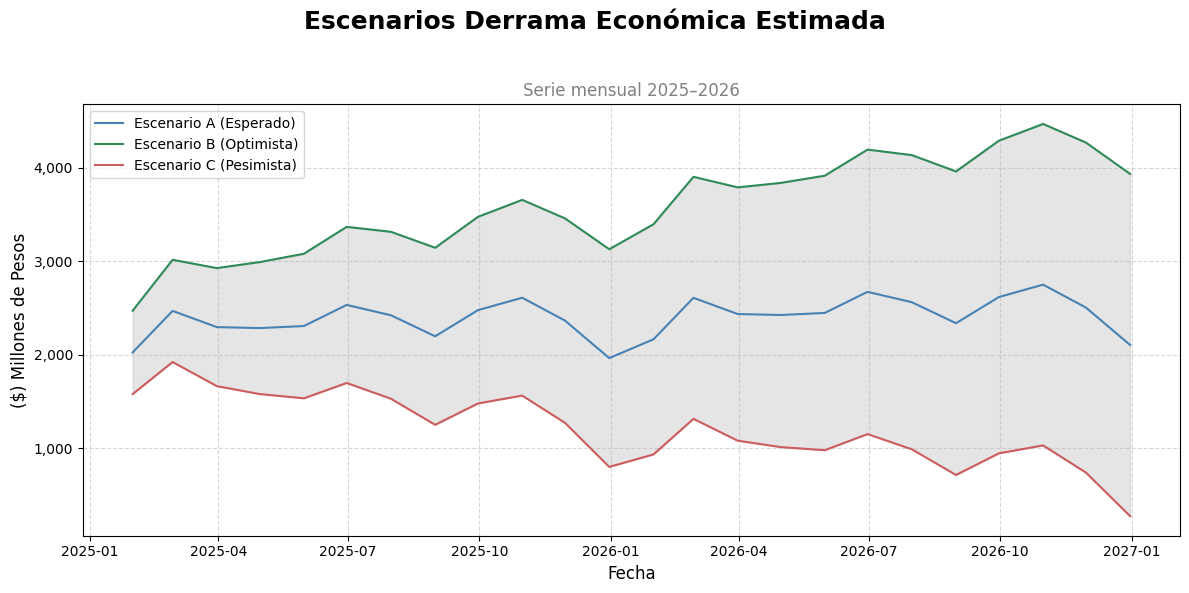

In [37]:
# Definir los tres escenarios:
# Escenario A: Predicción puntual
n_periods = 36
fitted, confint = smodel.predict(n_periods=n_periods, return_conf_int=True)
index_of_fc = pd.date_range(train_set.index[-1] + pd.DateOffset(months=1), periods = n_periods, freq='MS')

fitted_series = pd.Series(fitted, index=index_of_fc)
lower_series = pd.Series(confint[:, 0], index=index_of_fc)
upper_series = pd.Series(confint[:, 1], index=index_of_fc)

escenario_a = fitted.values

# Escenario B: Límite superior del intervalo de confianza (optimista)
escenario_b = confint[:, 1]

# Escenario C: Límite inferior del intervalo de confianza (pesimista)
escenario_c = confint[:, 0]

# Crear un DataFrame para los tres escenarios
escenarios_df = pd.DataFrame({
    'Escenario A (Esperado)': escenario_a,
    'Escenario B (Optimista)': escenario_b,
    'Escenario C (Pesimista)': escenario_c
}, index=pd.date_range(start='2024-12-01', periods=36, freq='M'))  # Asumiendo que son meses

# Filtrar solo las filas donde el año sea 2025 and 2026
escenarios_2025_6_df = escenarios_df[escenarios_df.index.year.isin([2025, 2026])]


# Mostrar los tres escenarios filtrados para 2025 and 2026
print(escenarios_2025_6_df)

# === Crear figura ===
fig, ax = plt.subplots(figsize=(12, 6))

# Líneas de los escenarios
ax.plot(escenarios_2025_6_df.index, escenarios_2025_6_df['Escenario A (Esperado)'], label='Escenario A (Esperado)', color='steelblue')
ax.plot(escenarios_2025_6_df.index, escenarios_2025_6_df['Escenario B (Optimista)'], label='Escenario B (Optimista)', color='seagreen')
ax.plot(escenarios_2025_6_df.index, escenarios_2025_6_df['Escenario C (Pesimista)'], label='Escenario C (Pesimista)', color='indianred')

# Banda de variación entre optimista y pesimista
ax.fill_between(escenarios_2025_6_df.index,
                escenarios_2025_6_df['Escenario B (Optimista)'],
                escenarios_2025_6_df['Escenario C (Pesimista)'],
                color='gray', alpha=0.2)

# Títulos tipo presentación
plt.suptitle("Escenarios Derrama Económica Estimada", fontsize=18, fontweight='bold')
plt.title("Serie mensual 2025–2026", fontsize=12, color='gray')

# Etiquetas
ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("($) Millones de Pesos", fontsize=12)

# Separadores de miles en el eje Y
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Leyenda y rejilla
ax.legend(loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)

# Layout final
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [38]:
# Agrupar por año y sumar los valores
suma_por_anio = escenarios_2025_6_df.groupby(escenarios_2025_6_df.index.year).sum()

# Mostrar los resultados
print("Suma de escenarios por año (2025 y 2026):")
print(suma_por_anio)

Suma de escenarios por año (2025 y 2026):
      Escenario A (Esperado)  Escenario B (Optimista)  Escenario C (Pesimista)
2025            27967.984393             38041.747510             17894.221276
2026            29645.185700             48097.828789             11192.542611


### Llegada Turistas Nacionales

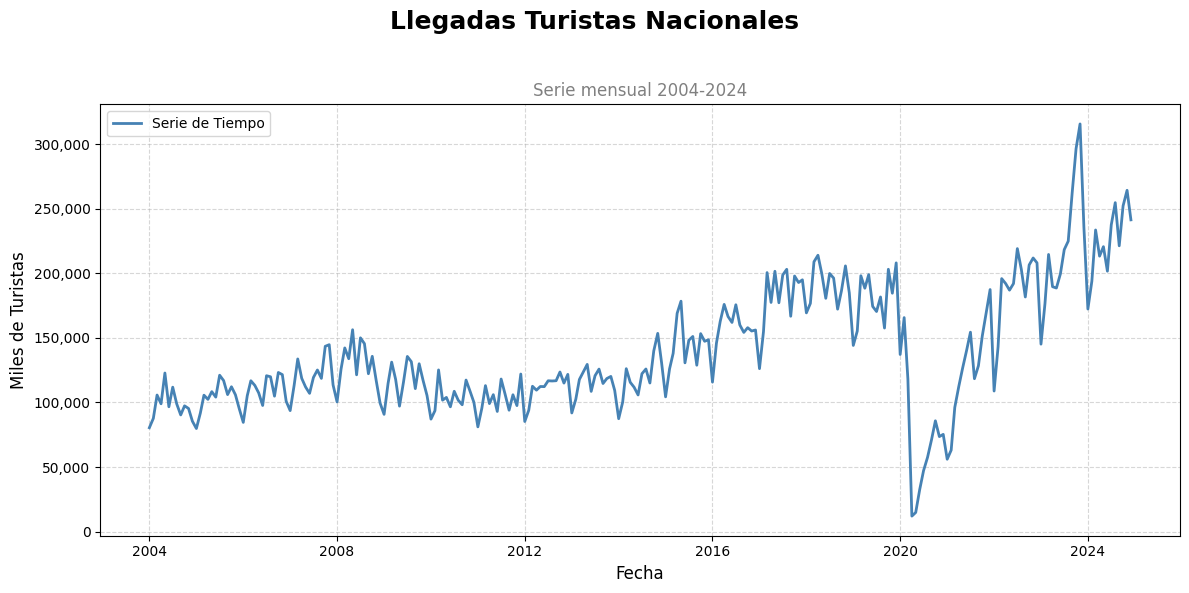

In [40]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_copy.index, df_copy['LLT_nat'], label="Serie de Tiempo", color="steelblue", linewidth=2)
plt.suptitle("Llegadas Turistas Nacionales", fontsize=18, fontweight='bold')
plt.title("Serie mensual 2004-2024", fontsize=12, color='gray')
ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("Miles de Turistas", fontsize=12)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend(loc='upper left')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### ACF Y PACF

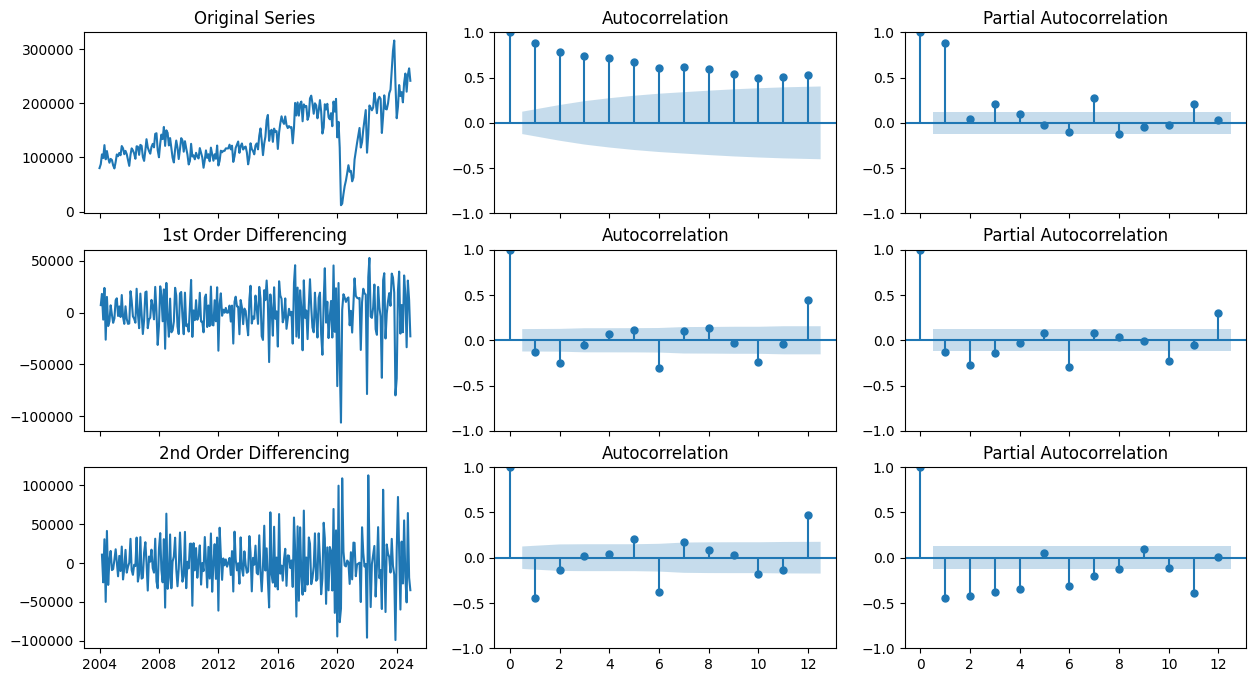

In [41]:
# Original Series
orig_data_value_LTT = df_copy['LLT_nat']
fig, axes = plt.subplots(3, 3, figsize=(15, 8),sharex='col')
axes[0, 0].plot(orig_data_value_LTT); axes[0, 0].set_title('Original Series')
plot_acf(orig_data_value_LTT, lags=12, ax=axes[0, 1])
plot_pacf(orig_data_value_LTT, lags=12, ax=axes[0, 2])

# 1st Differencing
first_diff_value = orig_data_value_LTT.diff()
axes[1, 0].plot(first_diff_value); axes[1, 0].set_title('1st Order Differencing')
plot_acf(first_diff_value.dropna(), lags=12, ax=axes[1, 1])
plot_pacf(first_diff_value.dropna(), lags=12, ax=axes[1, 2])

# 2nd Differencing
second_diff_value = orig_data_value_LTT.diff().diff()
axes[2, 0].plot(second_diff_value); axes[2, 0].set_title('2nd Order Differencing')
plot_acf(second_diff_value.dropna(), lags=12, ax=axes[2, 1])
plot_pacf(second_diff_value.dropna(), lags=12, ax=axes[2, 2])

plt.show()

In [42]:
print("Original Series")
result = adfuller(orig_data_value_LTT, autolag='AIC')
labels = ['ADF Test Statistic', 'p-value', '# Lags Used', 'Number of Observations Used']
for value, label in zip(result[:4], labels):
    print(f"{label} : {value}")

# Evaluación del p-valor

if result[1] <= 0.05:
    print("Se rechaza la hipótesis nula. La serie ES estacionaria.")
else:
    print("No se rechaza la hipótesis nula. La serie NO ES estacionaria.")

print("--------------------------")
print("1ra Diff")
result = adfuller(first_diff_value.dropna(), autolag='AIC')
labels = ['ADF Test Statistic', 'p-value', '# Lags Used', 'Number of Observations Used']
for value, label in zip(result[:4], labels):
    print(f"{label} : {value}")

# Evaluación del p-valor

if result[1] <= 0.05:
    print("Se rechaza la hipótesis nula. La serie ES estacionaria.")
else:
    print("No se rechaza la hipótesis nula. La serie NO ES estacionaria.")

print("--------------------------")
print("2da Diff")
result = adfuller(second_diff_value.dropna(), autolag='AIC')
labels = ['ADF Test Statistic', 'p-value', '# Lags Used', 'Number of Observations Used']
for value, label in zip(result[:4], labels):
    print(f"{label} : {value}")

# Evaluación del p-valor

if result[1] <= 0.05:
    print("Se rechaza la hipótesis nula. La serie ES estacionaria.")
else:
    print("No se rechaza la hipótesis nula. La serie NO ES estacionaria.")

Original Series
ADF Test Statistic : -1.8818099396317027
p-value : 0.34066607476608346
# Lags Used : 12
Number of Observations Used : 239
No se rechaza la hipótesis nula. La serie NO ES estacionaria.
--------------------------
1ra Diff
ADF Test Statistic : -4.776890120491219
p-value : 6.020104399972201e-05
# Lags Used : 13
Number of Observations Used : 237
Se rechaza la hipótesis nula. La serie ES estacionaria.
--------------------------
2da Diff
ADF Test Statistic : -7.834993745109493
p-value : 6.148908598419375e-12
# Lags Used : 15
Number of Observations Used : 234
Se rechaza la hipótesis nula. La serie ES estacionaria.


#### Modelos

In [43]:
exog_data_value= df_copy[['CDP', 'DOT', 'INPC', 'gasto_promedio', 'EPT','TPA']]
pct_train = 0.955

split_index = int(pct_train * len(orig_data_value_LTT))
split_index_exog = int(pct_train * len(exog_data_value))

train_set, test_set = np.split(orig_data_value_LTT, [split_index])
exog_train, exog_test = np.split(exog_data_value, [split_index_exog])

#### SARIMAX con AUTO_ARIMA

In [44]:
simplefilter(action='ignore', category=FutureWarning)
smodel = pm.auto_arima(train_set,
					     start_p=1, start_q=1, exog=exog_train,
                         test='adf',
                         max_p=3, max_q=3, m=12,
                         start_P=0, seasonal=True,
                         d=1, D=1, trace=True,
                         error_action='ignore',
                         suppress_warnings=True,
                         stepwise=True)

smodel.summary()

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=5120.866, Time=0.76 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=5196.861, Time=0.04 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=5147.608, Time=0.22 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=5098.344, Time=1.02 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=5197.100, Time=0.11 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=5122.510, Time=0.43 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=5122.458, Time=0.83 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=5148.141, Time=0.22 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=inf, Time=2.28 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=5102.724, Time=0.19 sec
 ARIMA(0,1,2)(0,1,1)[12]             : AIC=5122.626, Time=0.73 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=5119.995, Time=0.80 sec
 ARIMA(1,1,2)(0,1,1)[12]             : AIC=5122.743, Time=1.60 sec
 ARIMA(0,1,1)(0,1,1)[12] intercept   : AIC=5107.013, Time=1.25 sec

Best model:  ARIMA(0,1,

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  240
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -2546.172
Date:                            Sat, 31 May 2025   AIC                           5098.344
Time:                                    21:31:51   BIC                           5108.619
Sample:                                01-01-2004   HQIC                          5102.490
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0779      0.034     -2.280      0.023      -0.145      -0.011
ma.S.L12      -0.7787      0.041    -18.886      0.000      -0.859      -0.698
sigma2      3.162e+08   5.97e-11    5.3e+18      0.000    3.16e+08    3.16e+08
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):               769.03
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               5.09   Skew:                            -1.59
Prob(H) (two-sided):                  0.00   Kurtosis:                        11.44
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number    inf. Standard errors may be unstable.
"""

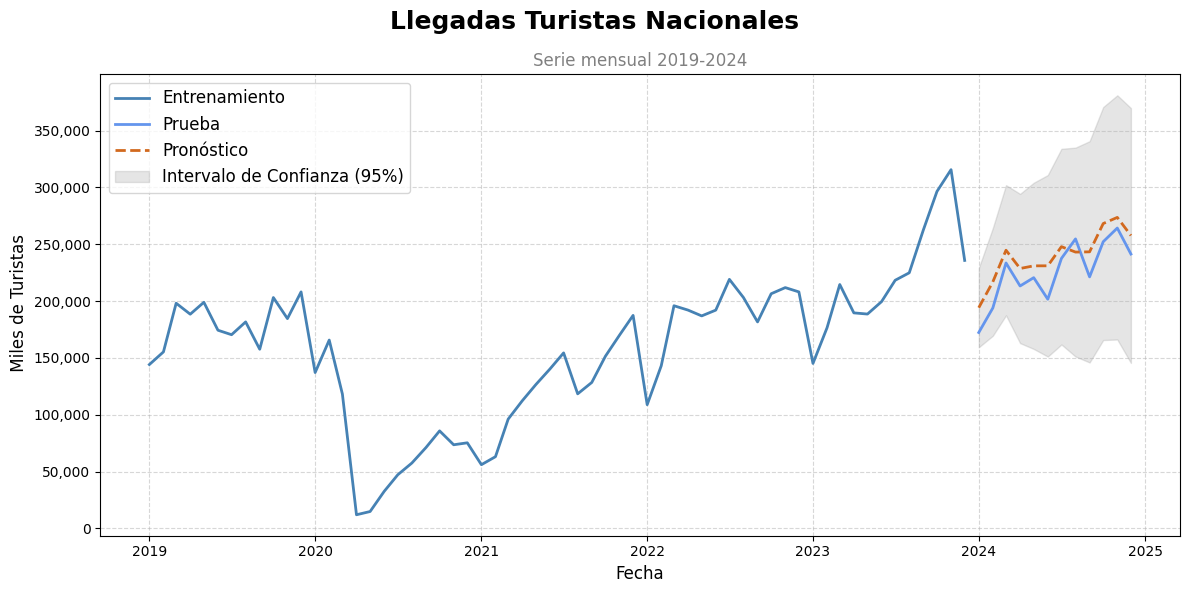

In [45]:
n_periods = 12
fitted, confint = smodel.predict(n_periods=n_periods, return_conf_int=True)
index_of_fc = pd.date_range(train_set.index[-1] + pd.DateOffset(months=1), periods = n_periods, freq='MS')

fitted_series = pd.Series(fitted, index=index_of_fc)
lower_series = pd.Series(confint[:, 0], index=index_of_fc)
upper_series = pd.Series(confint[:, 1], index=index_of_fc)

start_date = '2019-01-01'
train_filtered = train_set[train_set.index >= start_date]
test_filtered = test_set[test_set.index >= start_date]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(train_filtered, color='steelblue', linewidth=2, label='Entrenamiento')
ax.plot(test_filtered, color='cornflowerblue', linewidth=2, label='Prueba')
ax.plot(fitted_series[fitted_series.index >= start_date], color='chocolate', linestyle='--', linewidth=2, label='Pronóstico')

ax.fill_between(
    lower_series[lower_series.index >= start_date].index,
    lower_series[lower_series.index >= start_date],
    upper_series[upper_series.index >= start_date],
    color='gray', alpha=0.2, label='Intervalo de Confianza (95%)'
)

plt.suptitle("Llegadas Turistas Nacionales", fontsize=18, fontweight='bold')
plt.title("Serie mensual 2019-2024", fontsize=12, color='gray')
ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel(" Miles de Turistas", fontsize=12)
ax.legend(loc='upper left', fontsize=12)
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
#plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### SARIMAX con StatsModels

In [46]:
sarimax_model = sm.tsa.SARIMAX(train_set,
                               exog=exog_train,  # Variables exógenas
                               order=(0, 1, 1),  # ARIMA(p,d,q)
                               seasonal_order=(0, 1, 1, 12),  # Estacionalidad (P,D,Q,m)
                               enforce_stationarity=False,
                               enforce_invertibility=False)

sarimax_result = sarimax_model.fit()
print(sarimax_result.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                            LLT_nat   No. Observations:                  240
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -2317.794
Date:                            Sat, 31 May 2025   AIC                           4653.587
Time:                                    21:32:05   BIC                           4683.839
Sample:                                01-01-2004   HQIC                          4665.813
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
CDP                7.2639      4.245      1.711      0.087      -1.057      15.584
DOT             4.565e+

#### Gráfica Forecast 24 meses

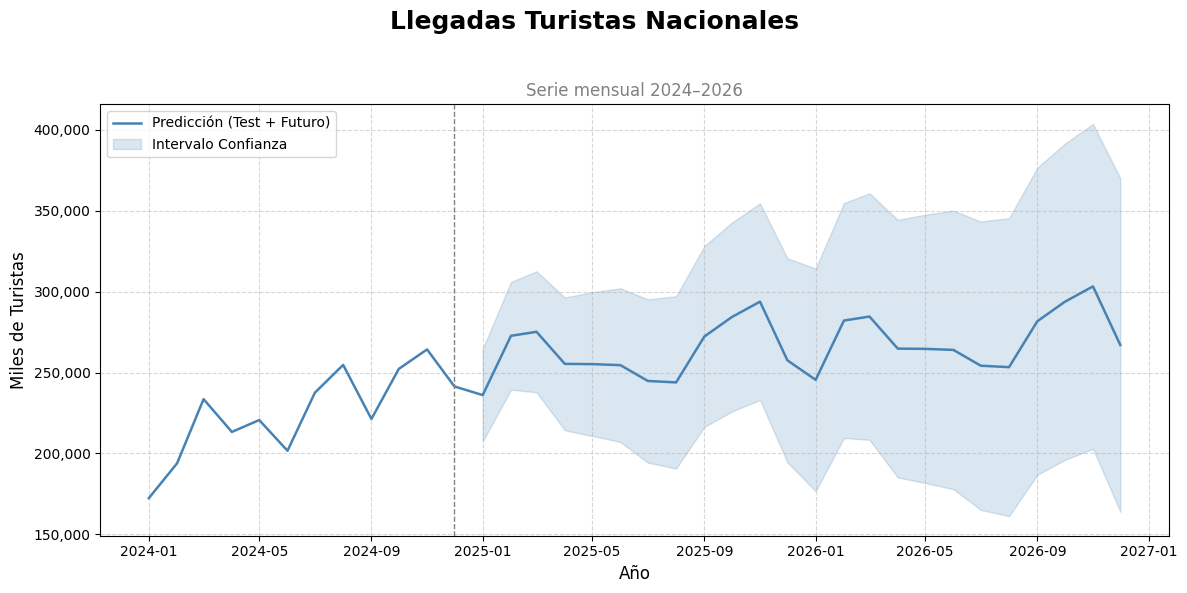

In [47]:
n_future_periods = 24

# ======== (1) Crear exog_future para 24 meses ========
# Usamos el promedio de las exógenas como ejemplo
exog_future = pd.DataFrame(
    np.tile(exog_test.mean().values, (n_future_periods, 1)),
    columns=exog_test.columns
)

# ======== (2) Crear índice mensual futuro ========
last_date = test_set.index[-1]
future_index = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=n_future_periods, freq='MS')

# ======== (3) Predicción del modelo SARIMAX ========
forecast = sarimax_result.get_forecast(steps=n_future_periods, exog=exog_future)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Crear series
forecast_series = pd.Series(forecast_mean.values, index=future_index)
lower_series = pd.Series(conf_int.iloc[:, 0].values, index=future_index)
upper_series = pd.Series(conf_int.iloc[:, 1].values, index=future_index)

# ======== (4) Combinar test + forecast para graficar últimos 36 meses ========
combined_series = pd.concat([test_set, forecast_series])
combined_lower = pd.concat([pd.Series([np.nan]*len(test_set), index=test_set.index), lower_series])
combined_upper = pd.concat([pd.Series([np.nan]*len(test_set), index=test_set.index), upper_series])

# ======== (5) Gráfico ========
# === (Gráfico) ===
fig, ax = plt.subplots(figsize=(12, 6))

# Línea de la serie
ax.plot(combined_series, color='steelblue', label='Predicción (Test + Futuro)', linewidth=1.8)

# Banda de intervalo de confianza
ax.fill_between(combined_series.index, combined_lower, combined_upper,
                color='steelblue', alpha=0.2, label='Intervalo Confianza')

# Línea vertical que indica el inicio de la predicción
ax.axvline(x=test_set.index[-1], color='gray', linestyle='--', linewidth=1)

# Títulos (al estilo de la imagen)
plt.suptitle("Llegadas Turistas Nacionales", fontsize=18, fontweight='bold')
plt.title("Serie mensual 2024–2026", fontsize=12, color='gray')

# Etiquetas de los ejes
ax.set_xlabel("Año", fontsize=12)
ax.set_ylabel("Miles de Turistas", fontsize=12)

# Formato de los números con coma (eje Y)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Rejilla
ax.grid(True, which='both', linestyle='--', alpha=0.5)

# Leyenda
ax.legend(loc='upper left')

# Ajustes finales
plt.tight_layout(rect=[0, 0, 1, 0.95])  # deja espacio para el título grande
plt.show()

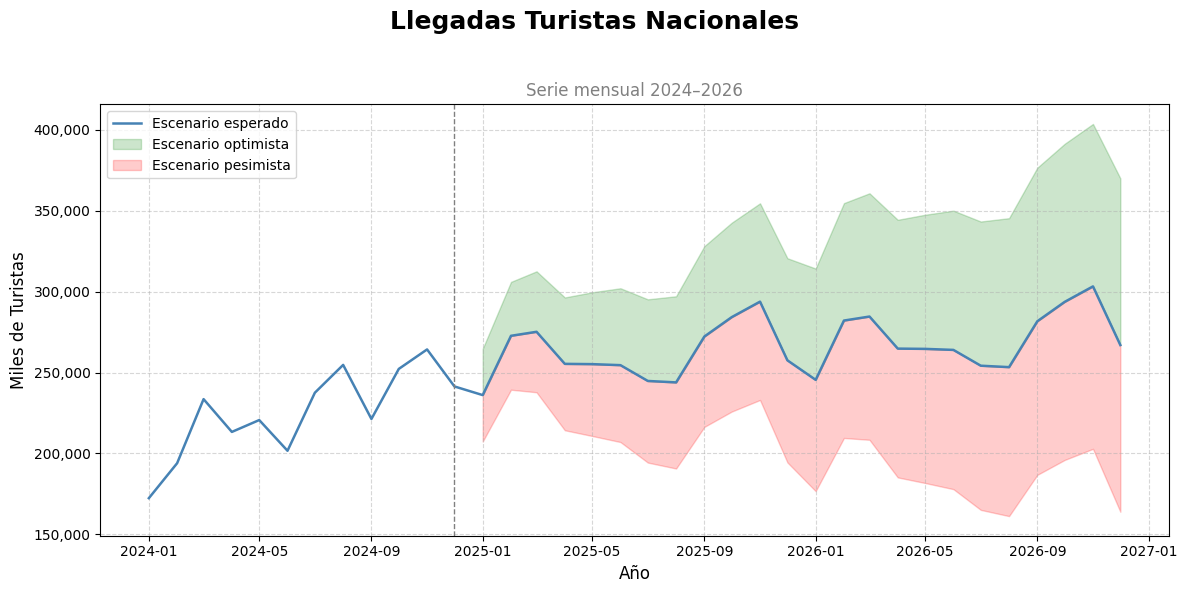

In [48]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# === Gráfico ===
fig, ax = plt.subplots(figsize=(12, 6))

# Línea central (predicción esperada)
ax.plot(combined_series, color='steelblue', label='Escenario esperado', linewidth=1.8)

# Banda superior: intervalo superior (optimista)
ax.fill_between(combined_series.index[12:], forecast_series, combined_upper[12:],
                color='green', alpha=0.2, label='Escenario optimista')

# Banda inferior: intervalo inferior (pesimista)
ax.fill_between(combined_series.index[12:], combined_lower[12:], forecast_series,
                color='red', alpha=0.2, label='Escenario pesimista')

# Línea vertical que indica el inicio de la predicción
ax.axvline(x=test_set.index[-1], color='gray', linestyle='--', linewidth=1)

# Títulos
plt.suptitle("Llegadas Turistas Nacionales", fontsize=18, fontweight='bold')
plt.title("Serie mensual 2024–2026", fontsize=12, color='gray')

# Ejes
ax.set_xlabel("Año", fontsize=12)
ax.set_ylabel("Miles de Turistas", fontsize=12)

# Formato del eje Y
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Rejilla
ax.grid(True, which='both', linestyle='--', alpha=0.5)

# Leyenda
ax.legend(loc='upper left')

# Ajuste de diseño
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### Métricas

In [49]:
Comparación = pd.DataFrame({
    "LLT Nacional real": test_set,
    "Predicciones": fitted,
    "Diferencia": fitted - test_set}
)
# Filtrar las filas donde el índice corresponda a 2024
Comparación = Comparación[Comparación.index.year == 2024]

In [50]:
# RMSE
rmse = np.sqrt((Comparación['Diferencia'] ** 2).mean())

# Porcentaje de error promedio
mean_actual = Comparación['LLT Nacional real'].mean()  # Asumiendo que 'Valor Real' es la columna con los valores reales
percentage_error = (rmse / mean_actual) * 100

# Imprimir los resultados
print(f"En promedio mi modelo se equivoca en: {rmse:.2f} unidades respecto a los valores reales")
print(f"El porcentaje de error promedio es: {percentage_error:.2f}%")

En promedio mi modelo se equivoca en: 17500.96 unidades respecto a los valores reales
El porcentaje de error promedio es: 7.76%


#### Escenarios OP, ES, PO

            Escenario A (Esperado)  Escenario B (Optimista)  \
2025-01-31              216,944.66               264,351.42   
2025-02-28              244,771.34               302,044.07   
2025-03-31              228,697.20               294,370.10   
2025-04-30              231,028.69               304,142.94   
2025-05-31              231,061.68               310,926.93   
2025-06-30              247,911.25               333,999.70   
2025-07-31              243,145.97               335,037.14   
2025-08-31              243,356.26               340,704.86   
2025-09-30              268,246.59               370,762.51   
2025-10-31              273,653.28               381,088.28   
2025-11-30              257,710.99               369,849.49   
2025-12-31              211,221.01               330,229.77   
2026-01-31              233,969.25               359,283.25   
2026-02-28              261,795.94               393,112.76   
2026-03-31              245,721.80               382,77

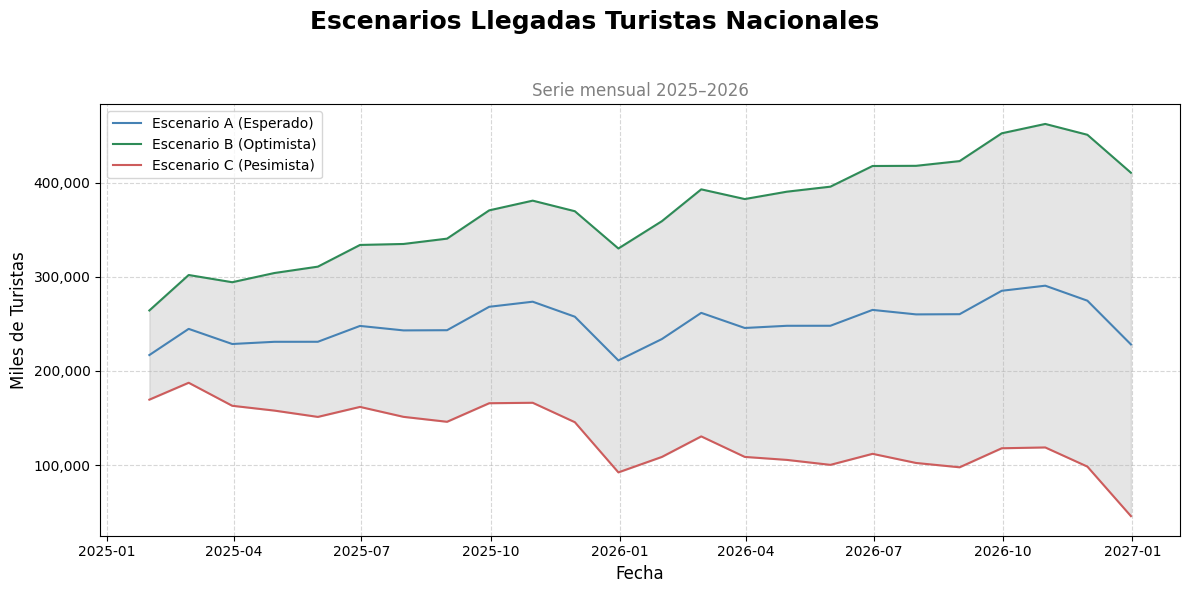

In [51]:
# Definir los tres escenarios:
# Escenario A: Predicción puntual
n_periods = 36
fitted, confint = smodel.predict(n_periods=n_periods, return_conf_int=True)
index_of_fc = pd.date_range(train_set.index[-1] + pd.DateOffset(months=1), periods = n_periods, freq='MS')

fitted_series = pd.Series(fitted, index=index_of_fc)
lower_series = pd.Series(confint[:, 0], index=index_of_fc)
upper_series = pd.Series(confint[:, 1], index=index_of_fc)
escenario_a = fitted.values

# Escenario B: Límite superior del intervalo de confianza (optimista)
escenario_b = confint[:, 1]

# Escenario C: Límite inferior del intervalo de confianza (pesimista)
escenario_c = confint[:, 0]

# Crear un DataFrame para los tres escenarios
escenarios_df = pd.DataFrame({
    'Escenario A (Esperado)': escenario_a,
    'Escenario B (Optimista)': escenario_b,
    'Escenario C (Pesimista)': escenario_c
}, index=pd.date_range(start='2024-12-01', periods=36, freq='M'))  # Asumiendo que son meses

# Filtrar solo las filas donde el año sea 2025 and 2026
escenarios_2025_6_df = escenarios_df[escenarios_df.index.year.isin([2025, 2026])]


# Mostrar los tres escenarios filtrados para 2025 and 2026
print(escenarios_2025_6_df)

# === Crear figura ===
fig, ax = plt.subplots(figsize=(12, 6))

# Líneas de los escenarios
ax.plot(escenarios_2025_6_df.index, escenarios_2025_6_df['Escenario A (Esperado)'], label='Escenario A (Esperado)', color='steelblue')
ax.plot(escenarios_2025_6_df.index, escenarios_2025_6_df['Escenario B (Optimista)'], label='Escenario B (Optimista)', color='seagreen')
ax.plot(escenarios_2025_6_df.index, escenarios_2025_6_df['Escenario C (Pesimista)'], label='Escenario C (Pesimista)', color='indianred')

# Banda de variación entre optimista y pesimista
ax.fill_between(escenarios_2025_6_df.index,
                escenarios_2025_6_df['Escenario B (Optimista)'],
                escenarios_2025_6_df['Escenario C (Pesimista)'],
                color='gray', alpha=0.2)

# Títulos tipo presentación
plt.suptitle("Escenarios Llegadas Turistas Nacionales", fontsize=18, fontweight='bold')
plt.title("Serie mensual 2025–2026", fontsize=12, color='gray')

# Etiquetas
ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("Miles de Turistas", fontsize=12)

# Separadores de miles en el eje Y
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Leyenda y rejilla
ax.legend(loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)

# Layout final
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [52]:
# Agrupar por año y sumar los valores
suma_por_anio = escenarios_2025_6_df.groupby(escenarios_2025_6_df.index.year).sum()

# Mostrar los resultados
print("Suma de escenarios por año (2025 y 2026):")
print(suma_por_anio)

Suma de escenarios por año (2025 y 2026):
      Escenario A (Esperado)  Escenario B (Optimista)  Escenario C (Pesimista)
2025            2,897,748.93             3,937,507.21             1,857,990.64
2026            3,102,044.08             4,958,120.25             1,245,967.90


### Llegada Turistas Extranjeros

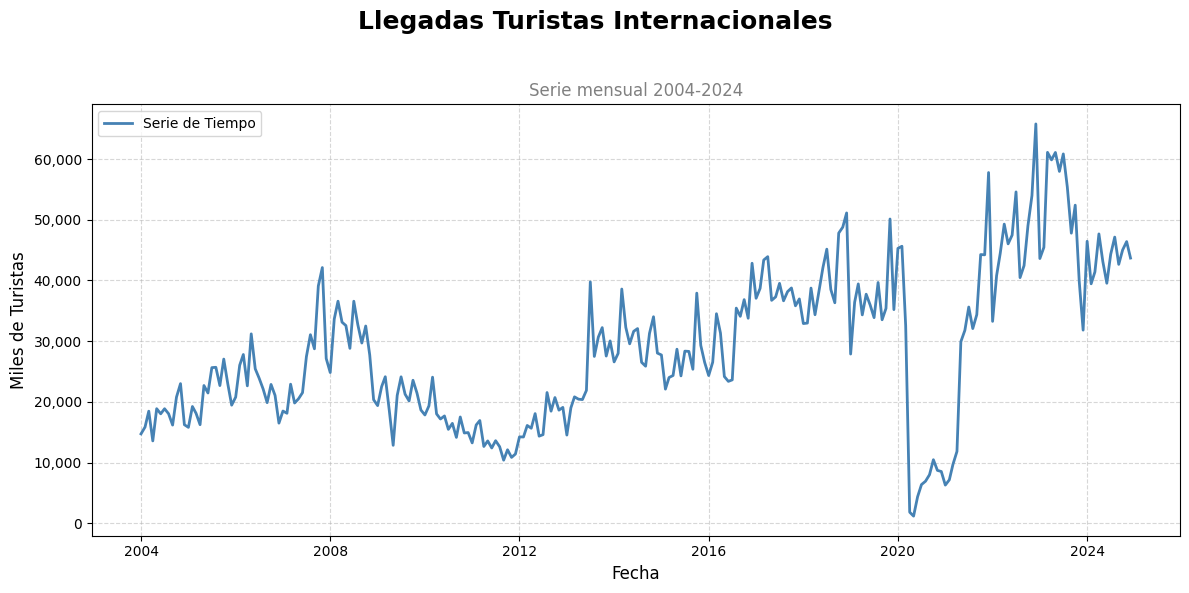

In [53]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_copy.index, df_copy['LLT_ext'], label="Serie de Tiempo", color="steelblue", linewidth=2)
plt.suptitle("Llegadas Turistas Internacionales", fontsize=18, fontweight='bold')
plt.title("Serie mensual 2004-2024", fontsize=12, color='gray')
ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("Miles de Turistas", fontsize=12)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend(loc='upper left')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### ACF Y PACF

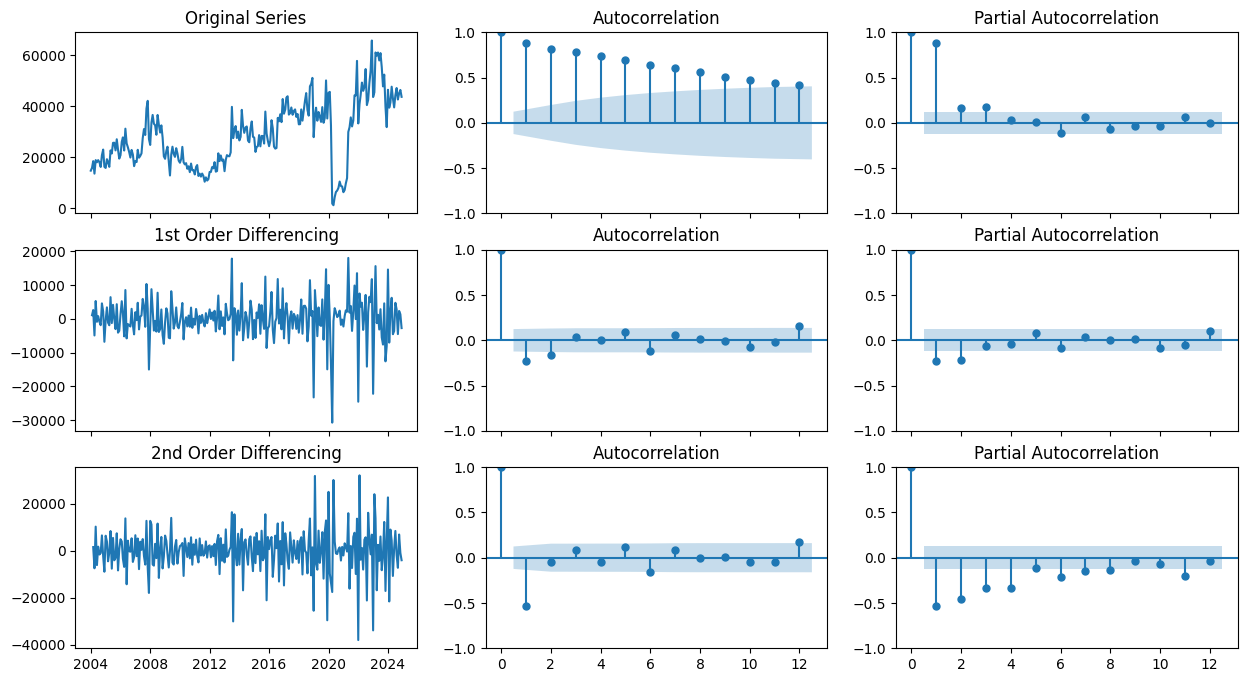

In [54]:
# Original Series
orig_data_value_LTT_ext = df_copy['LLT_ext']
fig, axes = plt.subplots(3, 3, figsize=(15, 8),sharex='col')
axes[0, 0].plot(orig_data_value_LTT_ext); axes[0, 0].set_title('Original Series')
plot_acf(orig_data_value_LTT_ext, lags=12, ax=axes[0, 1])
plot_pacf(orig_data_value_LTT_ext, lags=12, ax=axes[0, 2])

# 1st Differencing
first_diff_value = orig_data_value_LTT_ext.diff()
axes[1, 0].plot(first_diff_value); axes[1, 0].set_title('1st Order Differencing')
plot_acf(first_diff_value.dropna(), lags=12, ax=axes[1, 1])
plot_pacf(first_diff_value.dropna(), lags=12, ax=axes[1, 2])

# 2nd Differencing
second_diff_value = orig_data_value_LTT_ext.diff().diff()
axes[2, 0].plot(second_diff_value); axes[2, 0].set_title('2nd Order Differencing')
plot_acf(second_diff_value.dropna(), lags=12, ax=axes[2, 1])
plot_pacf(second_diff_value.dropna(), lags=12, ax=axes[2, 2])

plt.show()

In [55]:
print("Original Series")
result = adfuller(orig_data_value_LTT_ext, autolag='AIC')
labels = ['ADF Test Statistic', 'p-value', '# Lags Used', 'Number of Observations Used']
for value, label in zip(result[:4], labels):
    print(f"{label} : {value}")

# Evaluación del p-valor

if result[1] <= 0.05:
    print("Se rechaza la hipótesis nula. La serie ES estacionaria.")
else:
    print("No se rechaza la hipótesis nula. La serie NO ES estacionaria.")

print("--------------------------")
print("1ra Diff")
result = adfuller(first_diff_value.dropna(), autolag='AIC')
labels = ['ADF Test Statistic', 'p-value', '# Lags Used', 'Number of Observations Used']
for value, label in zip(result[:4], labels):
    print(f"{label} : {value}")

# Evaluación del p-valor

if result[1] <= 0.05:
    print("Se rechaza la hipótesis nula. La serie ES estacionaria.")
else:
    print("No se rechaza la hipótesis nula. La serie NO ES estacionaria.")

print("--------------------------")
print("2da Diff")
result = adfuller(second_diff_value.dropna(), autolag='AIC')
labels = ['ADF Test Statistic', 'p-value', '# Lags Used', 'Number of Observations Used']
for value, label in zip(result[:4], labels):
    print(f"{label} : {value}")

# Evaluación del p-valor

if result[1] <= 0.05:
    print("Se rechaza la hipótesis nula. La serie ES estacionaria.")
else:
    print("No se rechaza la hipótesis nula. La serie NO ES estacionaria.")

Original Series
ADF Test Statistic : -2.4820351325984293
p-value : 0.11990678110558067
# Lags Used : 2
Number of Observations Used : 249
No se rechaza la hipótesis nula. La serie NO ES estacionaria.
--------------------------
1ra Diff
ADF Test Statistic : -15.401011875672966
p-value : 3.215213660343301e-28
# Lags Used : 1
Number of Observations Used : 249
Se rechaza la hipótesis nula. La serie ES estacionaria.
--------------------------
2da Diff
ADF Test Statistic : -6.846034365739612
p-value : 1.7419043138655456e-09
# Lags Used : 15
Number of Observations Used : 234
Se rechaza la hipótesis nula. La serie ES estacionaria.


#### Modelos

In [56]:
exog_data_value= df_copy[['CDP', 'DOT', 'INPC', 'gasto_promedio', 'EPT','TPA']]
pct_train = 0.955

split_index = int(pct_train * len(orig_data_value_LTT_ext))
split_index_exog = int(pct_train * len(exog_data_value))

train_set, test_set = np.split(orig_data_value_LTT_ext, [split_index])
exog_train, exog_test = np.split(exog_data_value, [split_index_exog])

#### SARIMAX con AUTO_ARIMA

In [57]:
simplefilter(action='ignore', category=FutureWarning)
smodel = pm.auto_arima(train_set,
					     start_p=1, start_q=1, exog=exog_train,
                         test='adf',
                         max_p=3, max_q=3, m=12,
                         start_P=0, seasonal=True,
                         d=1, D=1, trace=True,
                         error_action='ignore',
                         suppress_warnings=True,
                         stepwise=True)

smodel.summary()

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=inf, Time=2.63 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=4706.369, Time=0.05 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=4664.554, Time=0.27 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=0.87 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=4703.045, Time=0.06 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=4643.796, Time=0.65 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=4621.456, Time=2.28 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=4622.444, Time=1.07 sec
 ARIMA(1,1,0)(2,1,2)[12]             : AIC=inf, Time=5.19 sec
 ARIMA(1,1,0)(1,1,2)[12]             : AIC=inf, Time=5.02 sec
 ARIMA(0,1,0)(2,1,1)[12]             : AIC=4602.308, Time=2.39 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=4605.533, Time=0.70 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=4636.948, Time=0.52 sec
 ARIMA(0,1,0)(2,1,2)[12]             : AIC=4610.071, Time=1.56 sec
 ARIMA(0,1,0)(1,1,0)[12]             : 

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  240
Model:             SARIMAX(0, 1, 0)x(2, 1, [1], 12)   Log Likelihood               -2297.154
Date:                              Sat, 31 May 2025   AIC                           4602.308
Time:                                      21:33:18   BIC                           4616.007
Sample:                                  01-01-2004   HQIC                          4607.836
                                       - 12-01-2023                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12      -0.0498      0.105     -0.475      0.635      -0.255       0.156
ar.S.L24      -0.1911      0.087     -2.206      0.027      -0.361      -0.021
ma.S.L12      -0.8042      0.074    -10.913      0.000      -0.949      -0.660
sigma2      4.336e+07    1.1e-09   3.95e+16      0.000    4.34e+07    4.34e+07
===================================================================================
Ljung-Box (L1) (Q):                   6.27   Jarque-Bera (JB):               178.14
Prob(Q):                              0.01   Prob(JB):                         0.00
Heteroskedasticity (H):               5.35   Skew:                            -0.55
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.20
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.53e+32. Standard errors may be unstable.
"""

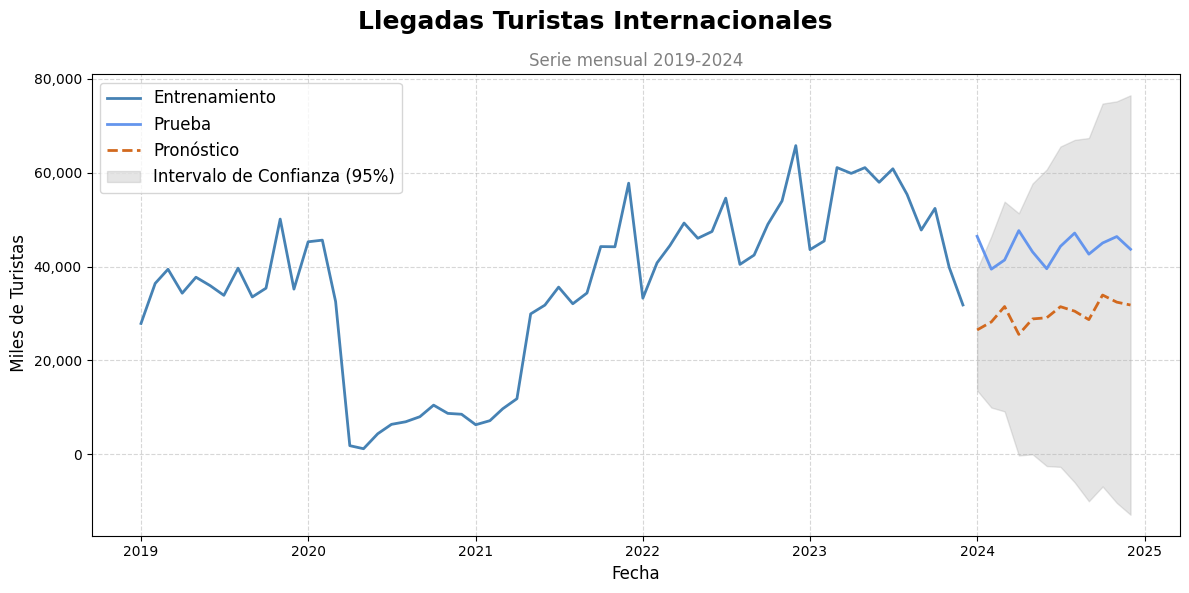

In [58]:
n_periods = 12
fitted, confint = smodel.predict(n_periods=n_periods, return_conf_int=True)
index_of_fc = pd.date_range(train_set.index[-1] + pd.DateOffset(months=1), periods = n_periods, freq='MS')

fitted_series = pd.Series(fitted, index=index_of_fc)
lower_series = pd.Series(confint[:, 0], index=index_of_fc)
upper_series = pd.Series(confint[:, 1], index=index_of_fc)

start_date = '2019-01-01'
train_filtered = train_set[train_set.index >= start_date]
test_filtered = test_set[test_set.index >= start_date]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(train_filtered, color='steelblue', linewidth=2, label='Entrenamiento')
ax.plot(test_filtered, color='cornflowerblue', linewidth=2, label='Prueba')
ax.plot(fitted_series[fitted_series.index >= start_date], color='chocolate', linestyle='--', linewidth=2, label='Pronóstico')

ax.fill_between(
    lower_series[lower_series.index >= start_date].index,
    lower_series[lower_series.index >= start_date],
    upper_series[upper_series.index >= start_date],
    color='gray', alpha=0.2, label='Intervalo de Confianza (95%)'
)

plt.suptitle("Llegadas Turistas Internacionales", fontsize=18, fontweight='bold')
plt.title("Serie mensual 2019-2024", fontsize=12, color='gray')
ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel(" Miles de Turistas", fontsize=12)
ax.legend(loc='upper left', fontsize=12)
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
#plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### SARIMAX con StatsModels

In [59]:
sarimax_model = sm.tsa.SARIMAX(train_set,
                               exog=exog_train,  # Variables exógenas
                               order=(0, 1, 0),  # ARIMA(p,d,q)
                               seasonal_order=(2, 1, 1, 12),  # Estacionalidad (P,D,Q,m)
                               enforce_stationarity=False,
                               enforce_invertibility=False)

sarimax_result = sarimax_model.fit()
print(sarimax_result.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                       
Dep. Variable:                              LLT_ext   No. Observations:                  240
Model:             SARIMAX(0, 1, 0)x(2, 1, [1], 12)   Log Likelihood               -2016.417
Date:                              Sat, 31 May 2025   AIC                           4052.834
Time:                                      21:39:00   BIC                           4085.966
Sample:                                  01-01-2004   HQIC                          4066.238
                                       - 12-01-2023                                         
Covariance Type:                                opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
CDP                2.1547      1.519      1.418      0.156      -0.823       5.132
DOT    

#### Gráfica Forecast 24 meses

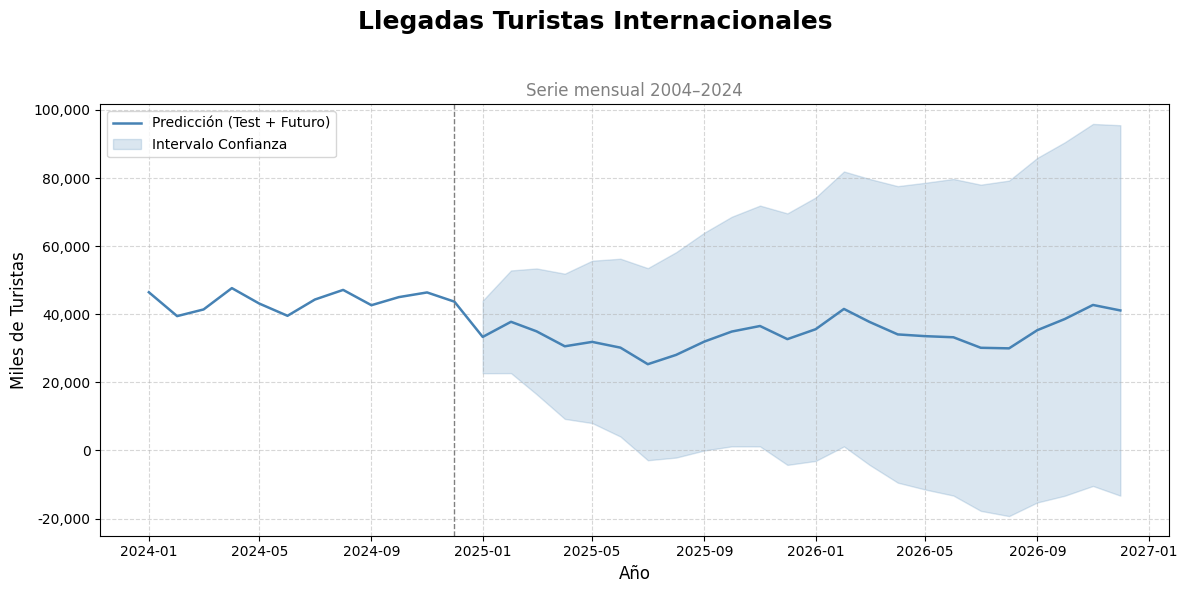

In [60]:
n_future_periods = 24

# ======== (1) Crear exog_future para 24 meses ========
# Usamos el promedio de las exógenas como ejemplo
exog_future = pd.DataFrame(
    np.tile(exog_test.mean().values, (n_future_periods, 1)),
    columns=exog_test.columns
)

# ======== (2) Crear índice mensual futuro ========
last_date = test_set.index[-1]
future_index = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=n_future_periods, freq='MS')

# ======== (3) Predicción del modelo SARIMAX ========
forecast = sarimax_result.get_forecast(steps=n_future_periods, exog=exog_future)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Crear series
forecast_series = pd.Series(forecast_mean.values, index=future_index)
lower_series = pd.Series(conf_int.iloc[:, 0].values, index=future_index)
upper_series = pd.Series(conf_int.iloc[:, 1].values, index=future_index)

# ======== (4) Combinar test + forecast para graficar últimos 36 meses ========
combined_series = pd.concat([test_set, forecast_series])
combined_lower = pd.concat([pd.Series([np.nan]*len(test_set), index=test_set.index), lower_series])
combined_upper = pd.concat([pd.Series([np.nan]*len(test_set), index=test_set.index), upper_series])

# === (Gráfico) ===
fig, ax = plt.subplots(figsize=(12, 6))

# Línea de la serie
ax.plot(combined_series, color='steelblue', label='Predicción (Test + Futuro)', linewidth=1.8)

# Banda de intervalo de confianza
ax.fill_between(combined_series.index, combined_lower, combined_upper,
                color='steelblue', alpha=0.2, label='Intervalo Confianza')

# Línea vertical que indica el inicio de la predicción
ax.axvline(x=test_set.index[-1], color='gray', linestyle='--', linewidth=1)

# Títulos (al estilo de la imagen)
plt.suptitle("Llegadas Turistas Internacionales", fontsize=18, fontweight='bold')
plt.title("Serie mensual 2004–2024", fontsize=12, color='gray')

# Etiquetas de los ejes
ax.set_xlabel("Año", fontsize=12)
ax.set_ylabel("Miles de Turistas", fontsize=12)

# Formato de los números con coma (eje Y)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Rejilla
ax.grid(True, which='both', linestyle='--', alpha=0.5)

# Leyenda
ax.legend(loc='upper left')

# Ajustes finales
plt.tight_layout(rect=[0, 0, 1, 0.95])  # deja espacio para el título grande
plt.show()

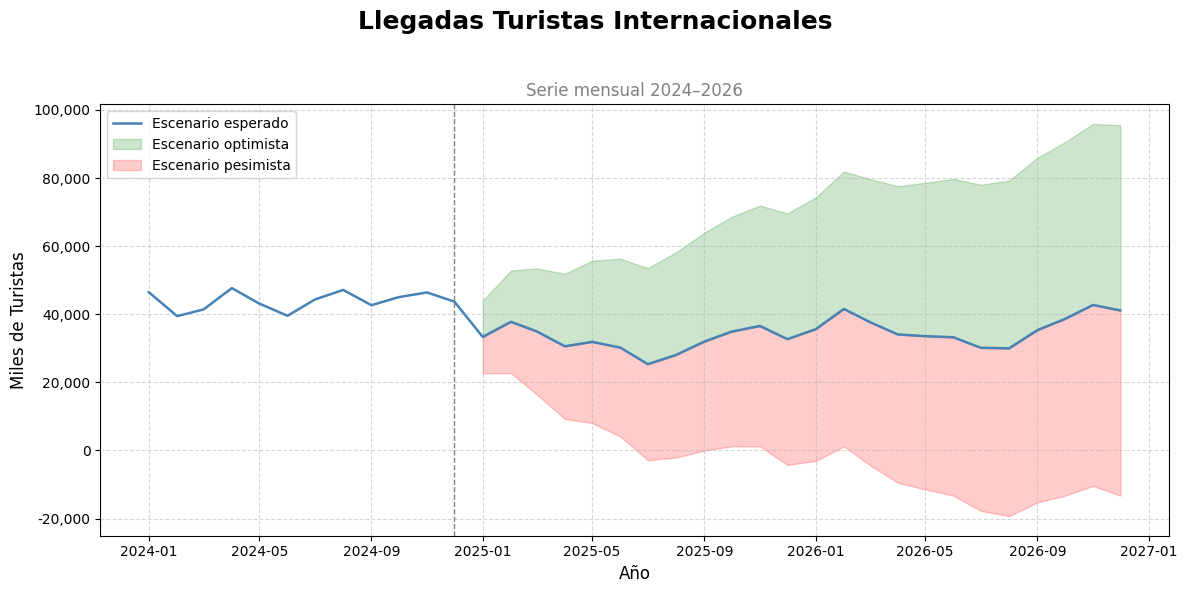

In [61]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# === Gráfico ===
fig, ax = plt.subplots(figsize=(12, 6))

# Línea central (predicción esperada)
ax.plot(combined_series, color='steelblue', label='Escenario esperado', linewidth=1.8)

# Banda superior: intervalo superior (optimista)
ax.fill_between(combined_series.index[12:], forecast_series, combined_upper[12:],
                color='green', alpha=0.2, label='Escenario optimista')

# Banda inferior: intervalo inferior (pesimista)
ax.fill_between(combined_series.index[12:], combined_lower[12:], forecast_series,
                color='red', alpha=0.2, label='Escenario pesimista')

# Línea vertical que indica el inicio de la predicción
ax.axvline(x=test_set.index[-1], color='gray', linestyle='--', linewidth=1)

# Títulos
plt.suptitle("Llegadas Turistas Internacionales", fontsize=18, fontweight='bold')
plt.title("Serie mensual 2024–2026", fontsize=12, color='gray')

# Ejes
ax.set_xlabel("Año", fontsize=12)
ax.set_ylabel("Miles de Turistas", fontsize=12)

# Formato del eje Y
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Rejilla
ax.grid(True, which='both', linestyle='--', alpha=0.5)

# Leyenda
ax.legend(loc='upper left')

# Ajuste de diseño
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### Métricas

In [62]:
Comparación = pd.DataFrame({
    "LLT Extranjero real": test_set,
    "Predicciones": fitted,
    "Diferencia": fitted - test_set}
)
# Filtrar las filas donde el índice corresponda a 2024
Comparación = Comparación[Comparación.index.year == 2024]

Comparación

,LLT Extranjero real,Predicciones,Diferencia
2024-01-01,46458,"26,494.45","-19,963.55"
2024-02-01,39452,"28,206.35","-11,245.65"
2024-03-01,41411,"31,486.81","-9,924.19"
2024-04-01,47671,"25,547.00","-22,124.00"
2024-05-01,43142,"28,845.85","-14,296.15"
2024-06-01,39544,"29,091.57","-10,452.43"
2024-07-01,44319,"31,450.70","-12,868.30"
2024-08-01,47146,"30,499.06","-16,646.94"
2024-09-01,42654,"28,692.30","-13,961.70"
2024-10-01,45026,"33,934.35","-11,091.65"


In [63]:
# RMSE
rmse = np.sqrt((Comparación['Diferencia'] ** 2).mean())

# Porcentaje de error promedio
mean_actual = Comparación['LLT Extranjero real'].mean()  # Asumiendo que 'Valor Real' es la columna con los valores reales
percentage_error = (rmse / mean_actual) * 100

# Imprimir los resultados
print(f"En promedio mi modelo se equivoca en: {rmse:.2f} unidades respecto a los valores reales")
print(f"El porcentaje de error promedio es: {percentage_error:.2f}%")

En promedio mi modelo se equivoca en: 14503.12 unidades respecto a los valores reales
El porcentaje de error promedio es: 33.03%


#### Escenarios OP, ES, PO

            Escenario A (Esperado)  Escenario B (Optimista)  \
2025-01-31               28,206.35                46,457.74   
2025-02-28               31,486.81                53,840.10   
2025-03-31               25,547.00                51,358.35   
2025-04-30               28,845.85                57,703.82   
2025-05-31               29,091.57                60,703.90   
2025-06-30               31,450.70                65,595.91   
2025-07-31               30,499.06                67,001.83   
2025-08-31               28,692.30                67,409.34   
2025-09-30               33,934.35                74,745.69   
2025-10-31               32,419.77                75,223.06   
2025-11-30               31,806.70                76,513.28   
2025-12-31               25,194.32                72,283.87   
2026-01-31               28,000.86                77,358.46   
2026-02-28               29,607.20                81,133.11   
2026-03-31               25,058.38                78,66

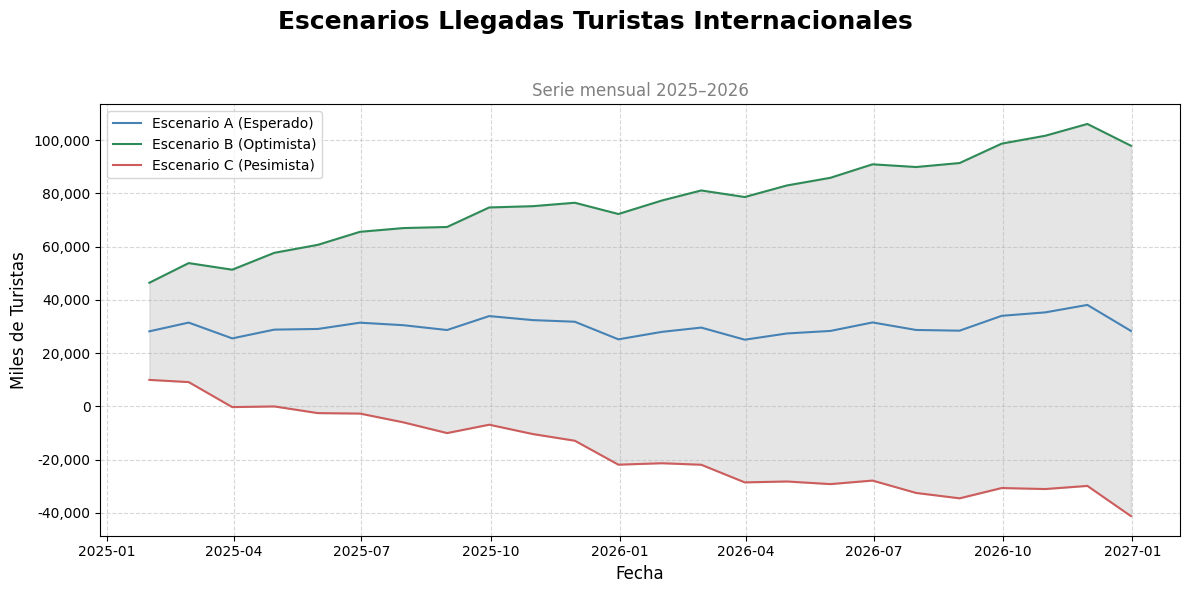

In [64]:
# Definir los tres escenarios:
# Escenario A: Predicción puntual
n_periods = 36
fitted, confint = smodel.predict(n_periods=n_periods, return_conf_int=True)
index_of_fc = pd.date_range(train_set.index[-1] + pd.DateOffset(months=1), periods = n_periods, freq='MS')

fitted_series = pd.Series(fitted, index=index_of_fc)
lower_series = pd.Series(confint[:, 0], index=index_of_fc)
upper_series = pd.Series(confint[:, 1], index=index_of_fc)

escenario_a = fitted.values

# Escenario B: Límite superior del intervalo de confianza (optimista)
escenario_b = confint[:, 1]

# Escenario C: Límite inferior del intervalo de confianza (pesimista)
escenario_c = confint[:, 0]

# Crear un DataFrame para los tres escenarios
escenarios_df = pd.DataFrame({
    'Escenario A (Esperado)': escenario_a,
    'Escenario B (Optimista)': escenario_b,
    'Escenario C (Pesimista)': escenario_c
}, index=pd.date_range(start='2024-12-01', periods=36, freq='M'))  # Asumiendo que son meses

# Filtrar solo las filas donde el año sea 2025 and 2026
escenarios_2025_6_df = escenarios_df[escenarios_df.index.year.isin([2025, 2026])]


# Mostrar los tres escenarios filtrados para 2025 and 2026
print(escenarios_2025_6_df)

# === Crear figura ===
fig, ax = plt.subplots(figsize=(12, 6))

# Líneas de los escenarios
ax.plot(escenarios_2025_6_df.index, escenarios_2025_6_df['Escenario A (Esperado)'], label='Escenario A (Esperado)', color='steelblue')
ax.plot(escenarios_2025_6_df.index, escenarios_2025_6_df['Escenario B (Optimista)'], label='Escenario B (Optimista)', color='seagreen')
ax.plot(escenarios_2025_6_df.index, escenarios_2025_6_df['Escenario C (Pesimista)'], label='Escenario C (Pesimista)', color='indianred')

# Banda de variación entre optimista y pesimista
ax.fill_between(escenarios_2025_6_df.index,
                escenarios_2025_6_df['Escenario B (Optimista)'],
                escenarios_2025_6_df['Escenario C (Pesimista)'],
                color='gray', alpha=0.2)

# Títulos tipo presentación
plt.suptitle("Escenarios Llegadas Turistas Internacionales", fontsize=18, fontweight='bold')
plt.title("Serie mensual 2025–2026", fontsize=12, color='gray')

# Etiquetas
ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("Miles de Turistas", fontsize=12)

# Separadores de miles en el eje Y
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Leyenda y rejilla
ax.legend(loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)

# Layout final
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [65]:
# Agrupar por año y sumar los valores
suma_por_anio = escenarios_2025_6_df.groupby(escenarios_2025_6_df.index.year).sum()

# Mostrar los resultados
print("Suma de escenarios por año (2025 y 2026):")
print(suma_por_anio)

Suma de escenarios por año (2025 y 2026):
      Escenario A (Esperado)  Escenario B (Optimista)  Escenario C (Pesimista)
2025              357,174.78               768,836.89               -54,487.33
2026              362,954.62             1,082,870.94              -356,961.70


## Normalidad Base de Datos - Turismo Z.T


In [66]:
df = pd.read_excel("Encuesta_Eventos_Nuevo_Leon.xlsx", sheet_name="Turismo_Z.T")

In [ ]:
normality_results = {}
for col in ['densidad_poblacion', 'pib_municipal','pib_turistico', 'pib_turistico_per_capita','pct_pobreza','tasa_criminalidad','ingreso_hogar_','ingreso_per_capita']:
    stat, p_value = shapiro(df[col])
    normality_results[col] = {'Estadístico W': stat, 'p-valor': p_value}
normality_df = pd.DataFrame(normality_results).T
normality_df['p-valor'] = normality_df['p-valor'].apply(lambda x: f"{x:.4f}")
normality_df

In [ ]:
normality_results = {}
for col in ['densidad_poblacion', 'pib_municipal','pib_turistico', 'pib_turistico_per_capita',
            'pct_pobreza','tasa_criminalidad','ingreso_hogar_','ingreso_per_capita']:

    stat_orig, p_orig = shapiro(df[col])
    col_log = df[col][df[col] > 0].apply(np.log)
    stat_log, p_log = shapiro(col_log)

    normality_results[col] = {
        'Estadístico W': stat_orig,
        'p-valor': p_orig,
        'p-valor (log)': p_log
    }

normality_df = pd.DataFrame(normality_results).T
normality_df['p-valor'] = normality_df['p-valor'].apply(lambda x: f"{x:.4f}")
normality_df['p-valor (log)'] = normality_df['p-valor (log)'].apply(lambda x: f"{x:.4f}")
normality_df

In [ ]:
!jupyter nbconvert --execute --to html "/content/PruebasH_Forecasts.ipynb"